# Version 29
## Version Log
- Imports
- Configuration
- **[SHARED] Data Loading**
- **[SHARED] Dataset Factory**
- ResNet18
- EfficientNet-B0 *(v2: unfreeze 3 blocks + augmentation + label smoothing)*
- VAE *(replaces DCGAN — stable on n=70)*
- **added CNN** for a model comparer
- GNN *(v2: safety guard ensures k-NN graphs before training)*

## Key changes
- Added CNN for comparer
- Added inference using real data (8 subject, 4 dyslexic and 4 non dyslexic)

> **How to add a new model:** call `get_image_loaders()`, `get_sequence_tensors()`,
> or `get_graph_data()` — no re-loading from disk.


In [ ]:
from datetime import datetime

def extract_products(base_url, pages=50, fetch_html_fn=None):
    fetcher = fetch_html_fn or _default_fetch_html
    all_products = []
    timestamp = datetime.now().isoformat()  

    for page in range(1, pages + 1):
        url = build_page_url(base_url, page)
        html = fetcher(url)
        products = parse_products_from_html(html)
        for p in products:
            p["timestamp"] = timestamp        
        all_products.extend(products)

    return all_products

### Imports

In [1]:
from google.colab import drive
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import os
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import KFold
import numpy as np
from tqdm.notebook import tqdm

from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
warnings.filterwarnings('ignore')
print("Imports OK")


Imports OK


### Configuration

In [2]:
drive.mount('/content/drive')

DATA_FOLDER = '/content/drive/MyDrive/TA_Project/dataset/data'
METADATA_FILE = '/content/drive/MyDrive/TA_Project/dataset/dyslexia_class_label.csv'
TARGET_TASK = "T5_Pseudo_Text"
SAMPLING_RATE       = 250
FIXATION_MIN_MS     = 40
FIXATION_MAX_DISP   = 1.0
SACCADE_MIN_VEL     = 15

REGRESSION_THRESHOLD   = 0
REGRESSION_MAX_AMP_DEG = 3.0
SCREEN_WIDTH_CM  = 47.0
SCREEN_WIDTH_PX  = 1680
VIEWING_DIST_CM  = 60
SCREEN_W = 1680
SCREEN_H = 1050

PX_PER_DEG = (SCREEN_WIDTH_PX / SCREEN_WIDTH_CM) * (VIEWING_DIST_CM * np.tan(np.deg2rad(1)))

WINDOW_SIZE_SEC = 4
WINDOW_OVERLAP  = 0.5

N_TOP_FEATURES  = 20
USE_LOOCV       = True

print(f"PX_PER_DEG : {PX_PER_DEG:.2f}")
print(f"CV strategy: {'LOOCV' if USE_LOOCV else 'K-Fold'}")

Mounted at /content/drive
PX_PER_DEG : 37.44
CV strategy: LOOCV


### Data Loading

In [3]:
# ════════════════════════════════════════════════════════════════
#  SHARED DATA LAYER  –  run once, reuse everywhere
#  Produces three module-level objects:
#    subject_dfs  : dict[str, pd.DataFrame]  (raw gaze per subject)
#    subject_labels : dict[str, int]         (0=normal, 1=dyslexic)
#    SUBJECT_IDS  : list[str]                (ordered, stable)
# ════════════════════════════════════════════════════════════════

def load_raw_subject(filepath):
    """
    Load one subject CSV.
    Returns DataFrame with columns:
      avg_x, avg_y, gaze_x_left, gaze_x_right,
      gaze_y_left, gaze_y_right, timestamp
    NaN rows = blinks — kept as-is.
    """
    with open(filepath, 'r') as f:
        first_line = f.readline()
    sep = ';' if ';' in first_line else ','
    df = pd.read_csv(filepath, sep=sep, low_memory=False)

    # Fix European decimal notation
    for col in df.columns:
        if df[col].dtype == object:
            try:
                df[col] = df[col].str.replace(',', '.', regex=False).astype(float)
            except (ValueError, AttributeError):
                pass

    def find_col(*kws):
        for col in df.columns:
            if all(k.lower() in col.lower() for k in kws):
                return col
        return None

    lx = find_col('gaze_x_left')  or find_col('left', 'x')
    rx = find_col('gaze_x_right') or find_col('right', 'x')
    ly = find_col('gaze_y_left')  or find_col('left', 'y')
    ry = find_col('gaze_y_right') or find_col('right', 'y')
    ts = find_col('timestamp')    or find_col('time')

    if not (lx and rx and ly and ry):
        raise ValueError(f"Gaze columns not found in: {filepath}")

    result = pd.DataFrame({
        'gaze_x_left' : df[lx].astype(float),
        'gaze_x_right': df[rx].astype(float),
        'gaze_y_left' : df[ly].astype(float),
        'gaze_y_right': df[ry].astype(float),
    })
    result['avg_x'] = (result['gaze_x_left']  + result['gaze_x_right']) / 2
    result['avg_y'] = (result['gaze_y_left']  + result['gaze_y_right']) / 2
    result['timestamp'] = (df[ts].astype(float) if ts
                           else np.arange(len(result)) * (1000.0 / SAMPLING_RATE))
    return result


def load_all_subjects():
    print("Loading metadata...")
    meta = pd.read_csv(METADATA_FILE, sep=',')
    meta['subject_id'] = meta['subject_id'].astype(str)

    subject_dfs, subject_labels = {}, {}
    files = os.listdir(DATA_FOLDER)
    print(f"Scanning {len(files)} files for task: {TARGET_TASK}")

    for filename in sorted(files):                         # sorted → stable order
        if TARGET_TASK in filename and 'raw.csv' in filename:
            subj_id = filename.split('_')[1]
            row = meta[meta['subject_id'] == subj_id]
            if row.empty:
                continue
            label = row['class_id'].values[0]
            try:
                df = load_raw_subject(os.path.join(DATA_FOLDER, filename))
                if len(df.dropna()) > 100:
                    subject_dfs[subj_id]    = df
                    subject_labels[subj_id] = int(label)
            except Exception as e:
                print(f"  ⚠ Skip {filename}: {e}")

    print(f"✓ Loaded {len(subject_dfs)} valid subjects")
    print(f"  Class distribution:")
    print(pd.Series(subject_labels).value_counts().rename({0:'normal', 1:'dyslexic'}).to_string())
    return subject_dfs, subject_labels


# ── Run once ─────────────────────────────────────────────────────
subject_dfs, subject_labels = load_all_subjects()
SUBJECT_IDS = list(subject_dfs.keys())          # stable ordered list
print(f"\nSUBJECT_IDS ready ({len(SUBJECT_IDS)} subjects)")


Loading metadata...
Scanning 839 files for task: T5_Pseudo_Text
✓ Loaded 70 valid subjects
  Class distribution:
normal      35
dyslexic    35

SUBJECT_IDS ready (70 subjects)


In [4]:
# ════════════════════════════════════════════════════════════════
#  DATASET FACTORY  –  produces ready-to-use inputs for any model
#
#  Available outputs:
#    get_image_loaders(transform, batch_size, k_folds)
#        → ImageFolder dataset  (for CNN / ResNet / EfficientNet / GAN)
#
#    get_sequence_tensors(max_len, normalize)
#        → X (N, T, 4), y (N,)  padded tensors  (for RNN / Transformer)
#
#    get_graph_data()
#        → list of torch_geometric.data.Data  (for GNN)
#
#  All functions read from the shared  subject_dfs / subject_labels
#  — no re-loading from disk.
# ════════════════════════════════════════════════════════════════

import torch
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import datasets as tv_datasets, transforms as tv_transforms
from sklearn.model_selection import KFold


# ── 1. IMAGE DATASET (CNN / ResNet / EfficientNet / GAN) ─────────

IMAGE_BASE_DIR = "/content/drive/MyDrive/TA_Project/dataset/improved_images"

def _render_images(image_dir, skip_existing=True):
    """Render scanpath images into image_dir/{dyslexic,normal}/subj_*.png."""
    os.makedirs(image_dir, exist_ok=True)
    rendered = 0
    for subj_id, df_raw in tqdm(subject_dfs.items(), desc="Rendering images"):
        label      = subject_labels[subj_id]
        label_name = "dyslexic" if label == 1 else "normal"
        save_dir   = os.path.join(image_dir, label_name)
        os.makedirs(save_dir, exist_ok=True)
        out_path   = os.path.join(save_dir, f"subj_{subj_id}.png")

        if skip_existing and os.path.exists(out_path):
            rendered += 1
            continue

        x = df_raw[["gaze_x_left","gaze_x_right"]].mean(axis=1).rolling(5, center=True).median().values
        y = df_raw[["gaze_y_left","gaze_y_right"]].mean(axis=1).rolling(5, center=True).median().values
        valid = ~(np.isnan(x) | np.isnan(y))
        x, y  = x[valid], y[valid]
        if len(x) < 50:
            continue

        from matplotlib.collections import LineCollection
        fig, ax = plt.subplots(figsize=(SCREEN_W/100, SCREEN_H/100), dpi=100)
        fig.patch.set_facecolor("black"); ax.set_facecolor("black")
        ax.set_xlim(0, SCREEN_W); ax.set_ylim(SCREEN_H, 0); ax.axis("off")

        points   = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        dx       = np.diff(x)
        colors   = [(1., 0., 0., 0.9) if d < -5 else (0., 0., 0., 0.) for d in dx]
        ax.add_collection(LineCollection(segments, colors=colors, linewidths=3))
        ax.scatter(x, y, color="white", s=8, alpha=0.15, zorder=3)

        plt.savefig(out_path, bbox_inches="tight", pad_inches=0, facecolor="black")
        plt.close(fig)
        rendered += 1

    print(f"✓ {rendered} images ready in {image_dir}")


def get_image_loaders(
    variant: str = "scanpath",           # folder name under IMAGE_BASE_DIR
    transform=None,
    batch_size: int = 8,
    k_folds: int = 5,
    render_if_missing: bool = True,
):
    """
    Returns:
        full_dataset  – ImageFolder (use .class_to_idx for label mapping)
        kfold_splits  – list of (train_idx, val_idx) tuples  (length = k_folds)
        get_loaders   – callable(fold_idx) → (train_loader, val_loader)
    """
    image_dir = os.path.join(IMAGE_BASE_DIR, variant)

    # Auto-render if the folder doesn't exist yet
    if render_if_missing and not os.path.isdir(image_dir):
        _render_images(image_dir)

    default_tf = tv_transforms.Compose([
        tv_transforms.Resize((224, 224)),
        tv_transforms.ToTensor(),
        tv_transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    full_dataset  = tv_datasets.ImageFolder(image_dir, transform=transform or default_tf)
    kfold         = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    kfold_splits  = list(kfold.split(full_dataset))

    def get_loaders(fold_idx: int):
        train_ids, val_ids = kfold_splits[fold_idx]
        train_loader = DataLoader(full_dataset, batch_size=batch_size,
                                  sampler=SubsetRandomSampler(train_ids))
        val_loader   = DataLoader(full_dataset, batch_size=batch_size,
                                  sampler=SubsetRandomSampler(val_ids))
        return train_loader, val_loader

    print(f"✓ Image dataset ready: {len(full_dataset)} images, "
          f"{len(full_dataset.classes)} classes, {k_folds}-fold CV")
    return full_dataset, kfold_splits, get_loaders


# ── 2. SEQUENCE TENSORS (RNN / Transformer / sequence GAN) ───────

def get_sequence_tensors(max_len: int = 2000, normalize: bool = True):
    """
    Pads / truncates each subject's gaze sequence to max_len.

    Returns:
        X  – torch.FloatTensor  (N, max_len, 4)
               columns: [avg_x, avg_y, gaze_x_left, gaze_x_right]
               (NaN filled with 0, mask provided separately)
        y  – torch.LongTensor   (N,)
        subject_ids – list[str] aligned with rows of X / y
        mask – torch.BoolTensor (N, max_len)  True = valid timestep
    """
    cols = ["avg_x", "avg_y", "gaze_x_left", "gaze_x_right"]
    seqs, ys = [], []

    for sid in SUBJECT_IDS:
        df  = subject_dfs[sid][cols].fillna(0).values
        lbl = subject_labels[sid]

        if len(df) >= max_len:
            seq = df[:max_len]
        else:
            pad = np.zeros((max_len - len(df), len(cols)))
            seq = np.vstack([df, pad])

        seqs.append(seq)
        ys.append(lbl)

    X = torch.FloatTensor(np.stack(seqs))           # (N, T, 4)
    y = torch.LongTensor(ys)                        # (N,)

    # Build padding mask  (True = valid timestep)
    mask_list = []
    for sid in SUBJECT_IDS:
        n = min(len(subject_dfs[sid]), max_len)
        m = torch.zeros(max_len, dtype=torch.bool)
        m[:n] = True
        mask_list.append(m)
    mask = torch.stack(mask_list)                   # (N, T)

    if normalize:
        # Normalize per-channel using training mean/std (all subjects here)
        mean = X[mask].mean(dim=0)
        std  = X[mask].std(dim=0).clamp(min=1e-6)
        X    = (X - mean) / std

    print(f"✓ Sequence tensors: X={tuple(X.shape)}, y={tuple(y.shape)}")
    return X, y, SUBJECT_IDS, mask


# ── 3. GRAPH DATA (GNN via torch_geometric) ───────────────────────

def get_graph_data(
    fixation_min_pts : int   = 6,
    max_fixations    : int   = 150,    # hard cap — prevents O(N²) edge explosion
    k_neighbors      : int   = 5,      # k-NN edges instead of radius — O(N×k)
):
    """
    Converts each subject's gaze into a fixation graph.

    Node features (4): [cx_norm, cy_norm, duration_ms, seq_position]
    Edges             : k-nearest-neighbour in 2-D screen space (k=5)
                        → each graph has at most max_fixations × k × 2 edges

    Compared to the old radius approach, k-NN edges are:
      • O(N×k) instead of O(N²)  → no OOM on dense fixation sequences
      • invariant to screen resolution changes

    Returns:
        data_list – list of torch_geometric.data.Data  (one per subject)
        y_list    – list of int labels (aligned)
    Requires:  pip install torch_geometric
    """
    try:
        from torch_geometric.data import Data
    except ImportError:
        raise ImportError("torch_geometric not installed. Run: pip install torch_geometric")

    def extract_fixations(df):
        """I-DT fixation extraction, returns array (F, 4)."""
        x  = df["avg_x"].values
        y  = df["avg_y"].values
        ts = df["timestamp"].values
        fixations = []
        i = 0
        while i < len(x) - fixation_min_pts:
            wx = x[i : i + fixation_min_pts]
            wy = y[i : i + fixation_min_pts]
            if (np.nanmax(wx) - np.nanmin(wx) <= FIXATION_MAX_DISP * PX_PER_DEG and
                np.nanmax(wy) - np.nanmin(wy) <= FIXATION_MAX_DISP * PX_PER_DEG):
                cx  = np.nanmean(wx)
                cy  = np.nanmean(wy)
                dur = ts[min(i + fixation_min_pts - 1, len(ts)-1)] - ts[i]
                fixations.append([cx, cy, dur, float(len(fixations))])
                i += fixation_min_pts
            else:
                i += 1
        arr = np.array(fixations) if fixations else np.zeros((1, 4))
        return arr

    def knn_edges(coords, k):
        """Build undirected k-NN edge_index from (F, 2) coords. CPU-only, fast."""
        F = len(coords)
        k = min(k, F - 1)
        if k <= 0:
            return torch.zeros((2, 0), dtype=torch.long)
        # pairwise distances
        diff = coords[:, None, :] - coords[None, :, :]   # (F, F, 2)
        dist = np.linalg.norm(diff, axis=-1)              # (F, F)
        np.fill_diagonal(dist, np.inf)
        nn_idx = np.argsort(dist, axis=1)[:, :k]          # (F, k)
        src = np.repeat(np.arange(F), k)
        dst = nn_idx.reshape(-1)
        # make undirected
        src_all = np.concatenate([src, dst])
        dst_all = np.concatenate([dst, src])
        edge_index = np.unique(np.stack([src_all, dst_all], axis=0), axis=1)
        return torch.tensor(edge_index, dtype=torch.long)

    data_list, y_list = [], []
    total_nodes, total_edges = 0, 0

    for sid in tqdm(SUBJECT_IDS, desc="Building graphs"):
        df    = subject_dfs[sid]
        label = subject_labels[sid]
        nodes = extract_fixations(df)                    # (F, 4)

        # ── Hard cap: keep top-N fixations by duration ────────────
        if len(nodes) > max_fixations:
            top_idx = np.argsort(nodes[:, 2])[::-1][:max_fixations]
            top_idx = np.sort(top_idx)                   # preserve sequence order
            nodes   = nodes[top_idx]

        # ── Normalise features ────────────────────────────────────
        nodes[:, 0] /= (SCREEN_W + 1e-6)                # cx → [0,1]
        nodes[:, 1] /= (SCREEN_H + 1e-6)                # cy → [0,1]
        nodes[:, 2]  = np.log1p(nodes[:, 2])            # log-duration
        nodes[:, 3] /= (len(nodes) + 1e-6)              # relative seq position

        # ── k-NN edges ────────────────────────────────────────────
        coords     = nodes[:, :2]
        edge_index = knn_edges(coords, k_neighbors)

        node_feats = torch.tensor(nodes, dtype=torch.float)
        data = Data(x=node_feats, edge_index=edge_index,
                    y=torch.tensor([label], dtype=torch.long))
        data_list.append(data)
        y_list.append(label)
        total_nodes += len(nodes)
        total_edges += edge_index.shape[1]

    avg_n = total_nodes / len(data_list)
    avg_e = total_edges / len(data_list)
    print(f"✓ Graph data ready: {len(data_list)} graphs  |  "
          f"avg nodes: {avg_n:.1f}  avg edges: {avg_e:.1f}")
    return data_list, y_list


print("\n✅ Dataset Factory loaded.")
print("  get_image_loaders()      → ImageFolder + KFold splits   (CNN / ResNet / GAN)")
print("  get_sequence_tensors()   → padded (N,T,4) tensors       (RNN / Transformer)")
print("  get_graph_data()         → torch_geometric Data list    (GNN)")



✅ Dataset Factory loaded.
  get_image_loaders()      → ImageFolder + KFold splits   (CNN / ResNet / GAN)
  get_sequence_tensors()   → padded (N,T,4) tensors       (RNN / Transformer)
  get_graph_data()         → torch_geometric Data list    (GNN)


In [5]:
# ════════════════════════════════════════════════════════════════
#  IMAGE RENDERING  – handled automatically by get_image_loaders()
#  Run this cell only if you want to pre-render images manually.
# ════════════════════════════════════════════════════════════════

IMAGE_DIR = os.path.join(IMAGE_BASE_DIR, "scanpath")
_render_images(IMAGE_DIR, skip_existing=True)


Rendering images:   0%|          | 0/70 [00:00<?, ?it/s]

✓ 70 images ready in /content/drive/MyDrive/TA_Project/dataset/improved_images/scanpath


### Training setup

In [6]:
# ════════════════════════════════════════════════════════════════
#  TRAINING SETUP – shared hyper-parameters
# ════════════════════════════════════════════════════════════════
import torch, torch.nn as nn, torch.optim as optim
from torch.optim import lr_scheduler

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
EPOCHS     = 50
K_FOLDS    = 5

print(f"Device : {device}")
print(f"Epochs : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  Folds : {K_FOLDS}")

# ── Prepare shared dataset objects ───────────────────────────────
full_dataset, kfold_splits, get_loaders = get_image_loaders(
    variant    = "scanpath",
    batch_size = BATCH_SIZE,
    k_folds    = K_FOLDS,
)


Device : cuda
Epochs : 50  |  Batch : 8  |  Folds : 5
✓ Image dataset ready: 70 images, 2 classes, 5-fold CV


#### ResNet18

In [7]:
# ════════════════════════════════════════════════════════════════
#  MODEL: ResNet18  (duplicate this section for other CNN models)
# ════════════════════════════════════════════════════════════════
from torchvision import models

fold_results_resnet = []

for fold in range(K_FOLDS):
    print(f"\n--- FOLD {fold + 1} / {K_FOLDS} ---")
    train_loader, val_loader = get_loaders(fold)
    _, val_ids = kfold_splits[fold]

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, 2))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam([
        {'params': model.layer4.parameters(), 'lr': 1e-4},
        {'params': model.fc.parameters(),     'lr': 1e-3},
    ], weight_decay=1e-4)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    best_fold_acc = 0.0
    for epoch in tqdm(range(EPOCHS), desc=f"ResNet18 Fold {fold+1}", leave=False):
        model.train()
        for inputs, batch_labels in train_loader:
            inputs, batch_labels = inputs.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), batch_labels)
            loss.backward(); optimizer.step()
        scheduler.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for inputs, batch_labels in val_loader:
                inputs, batch_labels = inputs.to(device), batch_labels.to(device)
                _, preds = torch.max(model(inputs), 1)
                correct += torch.sum(preds == batch_labels).item()
        acc = correct / len(val_ids)
        if acc > best_fold_acc:
            best_fold_acc = acc
            torch.save(model.state_dict(), f"resnet_weights_fold_{fold}.pth")

    print(f"Fold {fold+1} Peak Acc: {best_fold_acc:.4f}")
    fold_results_resnet.append(best_fold_acc)



--- FOLD 1 / 5 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


ResNet18 Fold 1:   0%|          | 0/50 [00:00<?, ?it/s]

Fold 1 Peak Acc: 0.6429

--- FOLD 2 / 5 ---


ResNet18 Fold 2:   0%|          | 0/50 [00:00<?, ?it/s]

...

Fold 3 Peak Acc: 0.8571

--- FOLD 4 / 5 ---


ResNet18 Fold 4:   0%|          | 0/50 [00:00<?, ?it/s]

Fold 4 Peak Acc: 0.7857

--- FOLD 5 / 5 ---


ResNet18 Fold 5:   0%|          | 0/50 [00:00<?, ?it/s]

Fold 5 Peak Acc: 0.8571


#### ResNet18 Result

In [8]:
avg_res = np.mean(fold_results_resnet)
std_res = np.std(fold_results_resnet)
print(f"\n{'='*65}")
print(f"  ResNet18 5-FOLD VERDICT: {avg_res:.4f}  (± {std_res:.4f})")
print(f"{'='*65}")



  ResNet18 5-FOLD VERDICT: 0.8286  (± 0.1161)


#### EfficientNet-B0

In [9]:
import torchvision.transforms as T
from torchvision import models as tv_models

effnet_train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.RandomErasing(p=0.3, scale=(0.02, 0.2)),

    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
effnet_val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Build two datasets: augmented for train, clean for val
effnet_train_ds, kfold_splits_eff, _ = get_image_loaders(
    variant="scanpath", transform=effnet_train_tf,
    batch_size=BATCH_SIZE, k_folds=K_FOLDS,
)
effnet_val_ds, _, _ = get_image_loaders(
    variant="scanpath", transform=effnet_val_tf,
    batch_size=BATCH_SIZE, k_folds=K_FOLDS,
)

def get_effnet_loaders(fold_idx):
    train_ids, val_ids = kfold_splits_eff[fold_idx]
    from torch.utils.data import SubsetRandomSampler
    return (
        DataLoader(effnet_train_ds, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(train_ids)),
        DataLoader(effnet_val_ds,   batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(val_ids)),
        val_ids,
    )

fold_results_effnet = []

for fold in range(K_FOLDS):
    print(f"\n--- FOLD {fold + 1} / {K_FOLDS} ---")
    train_loader, val_loader, val_ids = get_effnet_loaders(fold)

    model = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze all
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 3 feature blocks (features[6], [7], [8])
    for block_idx in [6, 7, 8]:
        for param in model.features[block_idx].parameters():
            param.requires_grad = True

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 2),
    )
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam([
        {'params': model.features[6].parameters(), 'lr': 1e-5},
        {'params': model.features[7].parameters(), 'lr': 5e-5},
        {'params': model.features[8].parameters(), 'lr': 2e-4},
        {'params': model.classifier.parameters(),  'lr': 1e-3},
    ], weight_decay=1e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_fold_acc = 0.0
    for epoch in tqdm(range(EPOCHS), desc=f"EfficientNet Fold {fold+1}", leave=False):
        model.train()
        for inputs, batch_labels in train_loader:
            inputs, batch_labels = inputs.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), batch_labels)
            loss.backward(); optimizer.step()
        scheduler.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for inputs, batch_labels in val_loader:
                inputs, batch_labels = inputs.to(device), batch_labels.to(device)
                _, preds = torch.max(model(inputs), 1)
                correct += torch.sum(preds == batch_labels).item()
        acc = correct / len(val_ids)
        if acc > best_fold_acc:
            best_fold_acc = acc

        torch.save(model.state_dict(), f"effnet_weights_fold_{fold}.pth")

    print(f"Fold {fold+1} Peak Acc: {best_fold_acc:.4f}")
    fold_results_effnet.append(best_fold_acc)


✓ Image dataset ready: 70 images, 2 classes, 5-fold CV
✓ Image dataset ready: 70 images, 2 classes, 5-fold CV

--- FOLD 1 / 5 ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 70.9MB/s]


EfficientNet Fold 1:   0%|          | 0/50 [00:00<?, ?it/s]

Fold 1 Peak Acc: 0.6429

--- FOLD 2 / 5 ---


EfficientNet Fold 2:   0%|          | 0/50 [00:00<?, ?it/s]

...

Fold 3 Peak Acc: 0.7857

--- FOLD 4 / 5 ---


EfficientNet Fold 4:   0%|          | 0/50 [00:00<?, ?it/s]

Fold 4 Peak Acc: 0.9286

--- FOLD 5 / 5 ---


EfficientNet Fold 5:   0%|          | 0/50 [00:00<?, ?it/s]

Fold 5 Peak Acc: 0.8571


In [10]:
import torch
import torch.nn as nn
from torchvision import models as tv_models

# 1. Bangun ulang kerangka model EfficientNet-B0
infer_effnet = tv_models.efficientnet_b0(weights=None)

# 2. Ubah layer classifier agar SAMA PERSIS dengan kode training Anda
in_features = infer_effnet.classifier[1].in_features
infer_effnet.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 2),
)

# 3. Load bobot hasil training
# PENTING: Pilih fold yang hasil akurasinya paling tinggi saat training!
# (Misal jika Fold 1 paling tinggi, gunakan fold_0.pth)
NAMA_FILE_WEIGHTS = "effnet_weights_fold_0.pth"

infer_effnet.load_state_dict(torch.load(NAMA_FILE_WEIGHTS, map_location=device))

# 4. Pindahkan ke device (GPU/CPU) dan set ke mode Evaluasi
infer_effnet = infer_effnet.to(device)
infer_effnet.eval()

print(f"✅ Model EfficientNet berhasil di-load dari {NAMA_FILE_WEIGHTS}!")

✅ Model EfficientNet berhasil di-load dari effnet_weights_fold_0.pth!


#### EfficientNet-B0 Result

In [11]:
avg_eff = np.mean(fold_results_effnet)
std_eff = np.std(fold_results_effnet)

print(f"\n{'='*65}")
print(f"  EfficientNet-B0 5-FOLD VERDICT: {avg_eff:.4f}  (± {std_eff:.4f})")
print(f"{'='*65}")

# ── Side-by-side comparison with ResNet18 ────────────────────────
print(f"\n{'Model':<20} {'Mean Acc':>10} {'Std':>8}")
print("-" * 40)
print(f"  {'ResNet18':<18} {np.mean(fold_results_resnet):>10.4f} {np.std(fold_results_resnet):>8.4f}")
print(f"  {'EfficientNet-B0':<18} {avg_eff:>10.4f} {std_eff:>8.4f}")

# ── Per-fold breakdown ───────────────────────────────────────────
print(f"\nPer-fold accuracy:")
print(f"  Fold  {'ResNet18':>10} {'EffNet-B0':>12}")
print(f"  {'─'*28}")
for i, (r, e) in enumerate(zip(fold_results_resnet, fold_results_effnet), 1):
    winner = " ← ResNet" if r > e else (" ← EffNet" if e > r else "")
    print(f"  {i:4d}  {r:>10.4f} {e:>12.4f}{winner}")



# ────────────────────────────────────────────────────────────────
#  ↓  PASTE YOUR NEXT MODEL BELOW  (GAN / GNN)
# ────────────────────────────────────────────────────────────────
# For image models:       train_loader, val_loader = get_loaders(fold)
# For GNN:                data_list, y_list = get_graph_data()
# For RNN / seq-GAN:      X, y, subject_ids, mask = get_sequence_tensors()
# ────────────────────────────────────────────────────────────────



  EfficientNet-B0 5-FOLD VERDICT: 0.8286  (± 0.1069)

Model                  Mean Acc      Std
----------------------------------------
  ResNet18               0.8286   0.1161
  EfficientNet-B0        0.8286   0.1069

Per-fold accuracy:
  Fold    ResNet18    EffNet-B0
  ────────────────────────────
     1      0.6429       0.6429
     2      1.0000       0.9286 ← ResNet
     3      0.8571       0.7857 ← ResNet
     4      0.7857       0.9286 ← EffNet
     5      0.8571       0.8571


#### GNN — Graph Convolutional Network (GCN)
> **Purpose:** classify dyslexia from fixation graphs.  
> Each subject's gaze is converted to a graph where nodes = fixations  
> and edges connect spatially nearby fixations.  
> Uses `get_graph_data()` from the Dataset Factory.

In [12]:

# ════════════════════════════════════════════════════════════════
#  GNN: Install torch_geometric + build graph dataset
#
#  IMPORTANT: must run AFTER the Dataset Factory cell (cell 7).
#  The factory must have the updated get_graph_data() with
#  max_fixations=150 and k_neighbors=5.
#  If you see "nodes: 5000+" here, re-run cell 7 first.
# ════════════════════════════════════════════════════════════════
import subprocess, sys

def install_pyg():
    import torch
    tv  = torch.__version__.split('+')[0]
    cu  = torch.version.cuda
    tag = f"cu{cu.replace('.','')}" if cu else "cpu"
    base = f"https://data.pyg.org/whl/torch-{tv}+{tag}.html"
    pkgs = ["torch_scatter","torch_sparse","torch_cluster",
            "torch_spline_conv","torch_geometric"]
    subprocess.check_call([sys.executable,"-m","pip","install",
                           "-q","--find-links",base]+pkgs)
    print("✓ torch_geometric installed")

try:
    import torch_geometric
    print(f"✓ torch_geometric {torch_geometric.__version__} already available")
except ImportError:
    install_pyg()

# ── Build graph dataset with node/edge caps ───────────────────────
data_list, y_list = get_graph_data(
    fixation_min_pts = 6,
    max_fixations    = 150,
    k_neighbors      = 5,
)

n0       = data_list[0]
max_n    = max(d.x.shape[0]           for d in data_list)
max_e    = max(d.edge_index.shape[1]  for d in data_list)
avg_n    = sum(d.x.shape[0]           for d in data_list) / len(data_list)
avg_e    = sum(d.edge_index.shape[1]  for d in data_list) / len(data_list)

print(f"\nSample graph  — nodes: {n0.x.shape[0]}, edges: {n0.edge_index.shape[1]}, label: {n0.y.item()}")
print(f"Max nodes     : {max_n}  (should be ≤ 150)")
print(f"Max edges     : {max_e}  (should be ≤ 1,500)")
print(f"Avg nodes     : {avg_n:.1f}  |  Avg edges: {avg_e:.1f}")

if max_n > 150:
    print("\n⚠ WARNING: max_nodes > 150 — re-run the Dataset Factory cell (cell 7) first.")
else:
    print("\n✓ Graph size OK — safe to run training cell.")


✓ torch_geometric installed


Building graphs:   0%|          | 0/70 [00:00<?, ?it/s]

✓ Graph data ready: 70 graphs  |  avg nodes: 150.0  avg edges: 907.5

Sample graph  — nodes: 150, edges: 936, label: 0
Max nodes     : 150  (should be ≤ 150)
Max edges     : 960  (should be ≤ 1,500)
Avg nodes     : 150.0  |  Avg edges: 907.5

✓ Graph size OK — safe to run training cell.


In [148]:
# ════════════════════════════════════════════════════════════════
#  GNN: Architecture — 3-layer GCN with global mean pooling
#
#  Node features (4): [cx, cy, duration_ms, pupil_proxy]
#  Graph-level output: binary classification (dyslexic / normal)
# ════════════════════════════════════════════════════════════════
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm
import torch.nn.functional as F

GNN_HIDDEN  = 128
GNN_EPOCHS  = 150
GNN_LR      = 1e-3
GNN_FOLDS   = 5
NODE_FEATS  = 4


class DyslexiaGCN(nn.Module):
    """
    3-layer GCN → global mean pool → 2-layer MLP → class logits
    """
    def __init__(self, in_channels=NODE_FEATS, hidden=GNN_HIDDEN, n_classes=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.bn1   = BatchNorm(hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.bn2   = BatchNorm(hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.bn3   = BatchNorm(hidden)

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x, edge_index, batch):
        # ── 3 GCN layers with residual-style skip ────────────────
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        # ── Graph-level pooling ───────────────────────────────────
        x = global_mean_pool(x, batch)          # (num_graphs, hidden)
        return self.head(x)                      # (num_graphs, 2)


print(f"DyslexiaGCN params: "
      f"{sum(p.numel() for p in DyslexiaGCN().parameters()):,}")


DyslexiaGCN params: 42,818


In [155]:
# ════════════════════════════════════════════════════════════════
#  GNN: K-Fold cross-validation training
#
#  OOM fix applied:
#    • batch_size reduced to 4 (graphs vary wildly in node count)
#    • gradient accumulation over 4 steps → effective batch = 16
#    • torch.cuda.empty_cache() + del model between folds
#    • graphs capped at 150 nodes / k-NN=5 edges (see Dataset Factory)
# ════════════════════════════════════════════════════════════════
from torch_geometric.loader import DataLoader as PyGLoader
from sklearn.model_selection import StratifiedKFold

fold_results_gnn = []
y_arr            = np.array(y_list)
ACCUM_STEPS      = 12          # gradient accumulation → effective batch = 16
ES_PATIENCE      = 75         # early stopping patience (epochs)

skf = StratifiedKFold(n_splits=GNN_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(data_list, y_arr)):
    print(f"\n--- FOLD {fold + 1} / {GNN_FOLDS} ---")

    # ── Free GPU memory from previous fold ───────────────────────
    if fold > 0:
        del model_gnn, opt_gnn, sched_gnn
        torch.cuda.empty_cache()

    train_data = [data_list[i] for i in train_idx]
    val_data   = [data_list[i] for i in val_idx]

    # batch_size=4: small enough for variable-size fixation graphs
    train_loader_gnn = PyGLoader(train_data, batch_size=4, shuffle=True)
    val_loader_gnn   = PyGLoader(val_data,   batch_size=4, shuffle=False)

    model_gnn = DyslexiaGCN().to(device)
    opt_gnn   = optim.Adam(model_gnn.parameters(), lr=GNN_LR, weight_decay=1e-4)
    sched_gnn = lr_scheduler.CosineAnnealingLR(opt_gnn, T_max=GNN_EPOCHS)
    crit_gnn  = nn.CrossEntropyLoss()

    best_fold_acc  = 0.0
    es_counter     = 0         # epochs since last improvement

    for epoch in tqdm(range(GNN_EPOCHS), desc=f"GNN Fold {fold+1}", leave=False):
        # ── Train (gradient accumulation) ────────────────────────
        model_gnn.train()
        opt_gnn.zero_grad()

        for step, batch in enumerate(train_loader_gnn):
            batch = batch.to(device)
            out   = model_gnn(batch.x, batch.edge_index, batch.batch)
            loss  = crit_gnn(out, batch.y.squeeze()) / ACCUM_STEPS
            loss.backward()

            if (step + 1) % ACCUM_STEPS == 0:
                opt_gnn.step()
                opt_gnn.zero_grad()

        # flush any remainder
        opt_gnn.step()
        opt_gnn.zero_grad()
        sched_gnn.step()

        # ── Validate ─────────────────────────────────────────────
        model_gnn.eval()
        correct = 0
        with torch.no_grad():
            for batch in val_loader_gnn:
                batch = batch.to(device)
                out   = model_gnn(batch.x, batch.edge_index, batch.batch)
                preds = out.argmax(dim=1)
                correct += (preds == batch.y.squeeze()).sum().item()

        acc = correct / len(val_data)
        if acc > best_fold_acc:
            torch.save(model_gnn.state_dict(), f"gcn_weights_fold_{fold}.pth")
            best_fold_acc = acc
            es_counter    = 0             # reset patience
        else:
            es_counter += 1
            if es_counter >= ES_PATIENCE:
                tqdm.write(f"  Early stop @ epoch {epoch+1} (no improvement for {ES_PATIENCE} epochs)")
                break

    print(f"Fold {fold+1} Peak Acc: {best_fold_acc:.4f}")
    fold_results_gnn.append(best_fold_acc)


torch.cuda.empty_cache()   # final cleanup


--- FOLD 1 / 5 ---


GNN Fold 1:   0%|          | 0/150 [00:00<?, ?it/s]

  Early stop @ epoch 105 (no improvement for 75 epochs)
Fold 1 Peak Acc: 0.9286

--- FOLD 2 / 5 ---


GNN Fold 2:   0%|          | 0/150 [00:00<?, ?it/s]

  Early stop @ epoch 77 (no improvement for 75 epochs)
Fold 2 Peak Acc: 1.0000

--- FOLD 3 / 5 ---


...

  Early stop @ epoch 79 (no improvement for 75 epochs)
Fold 3 Peak Acc: 0.7143

--- FOLD 4 / 5 ---


GNN Fold 4:   0%|          | 0/150 [00:00<?, ?it/s]

  Early stop @ epoch 127 (no improvement for 75 epochs)
Fold 4 Peak Acc: 0.9286

--- FOLD 5 / 5 ---


GNN Fold 5:   0%|          | 0/150 [00:00<?, ?it/s]

  Early stop @ epoch 88 (no improvement for 75 epochs)
Fold 5 Peak Acc: 0.9286


In [156]:
# ════════════════════════════════════════════════════════════════
#  GNN: Results + full model comparison
# ════════════════════════════════════════════════════════════════
avg_gnn = np.mean(fold_results_gnn)
std_gnn = np.std(fold_results_gnn)

print(f"\n{'='*65}")
print(f"  GCN 5-FOLD VERDICT: {avg_gnn:.4f}  (± {std_gnn:.4f})")
print(f"{'='*65}")

# ── Full model comparison table ───────────────────────────────────
results = {
    'ResNet18'       : fold_results_resnet,
    'EfficientNet-B0': fold_results_effnet,
    'GCN (GNN)'      : fold_results_gnn,
}

print(f"\n{'─'*55}")
print(f"  {'Model':<22} {'Mean Acc':>10} {'Std':>8} {'Best Fold':>11}")
print(f"  {'─'*51}")
for name, folds in results.items():
    print(f"  {name:<22} {np.mean(folds):>10.4f} {np.std(folds):>8.4f} {max(folds):>11.4f}")
print(f"{'─'*55}")

# ── Per-fold breakdown ────────────────────────────────────────────
print(f"\nPer-fold accuracy:")
header = f"  {'Fold':>4}  {'ResNet18':>10} {'EffNet-B0':>11} {'GCN':>8}"
print(header)
print(f"  {'─'*len(header.rstrip())}")
for i, (r, e, g) in enumerate(zip(fold_results_resnet, fold_results_effnet, fold_results_gnn), 1):
    best = max(r, e, g)
    tags = (
        " ← ResNet" if r == best and r > e and r > g else
        " ← EffNet" if e == best and e > r and e > g else
        " ← GCN"    if g == best and g > r and g > e else
        " ← tie"
    )
    print(f"  {i:4d}  {r:>10.4f} {e:>11.4f} {g:>8.4f}{tags}")

# ────────────────────────────────────────────────────────────────
#  ↓  NEXT: CNN section
# ────────────────────────────────────────────────────────────────



  GCN 5-FOLD VERDICT: 0.9000  (± 0.0969)

───────────────────────────────────────────────────────
  Model                    Mean Acc      Std   Best Fold
  ───────────────────────────────────────────────────
  ResNet18                   0.8286   0.1161      1.0000
  EfficientNet-B0            0.8286   0.1069      0.9286
  GCN (GNN)                  0.9000   0.0969      1.0000
───────────────────────────────────────────────────────

Per-fold accuracy:
  Fold    ResNet18   EffNet-B0      GCN
  ───────────────────────────────────────
     1      0.6429      0.6429   0.9286 ← GCN
     2      1.0000      0.9286   1.0000 ← tie
     3      0.8571      0.7857   0.7143 ← ResNet
     4      0.7857      0.9286   0.9286 ← tie
     5      0.8571      0.8571   0.9286 ← GCN


#### CNN (3 Simple Layer)

In [16]:
# ════════════════════════════════════════════════════════════════
#  MODEL: Simple 3-Layer CNN  (scratch, no pretrained weights)
#  Plug-in baseline to compare against GCN
# ════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import numpy as np

# ── Architecture ─────────────────────────────────────────────────
class SimpleCNN(nn.Module):
    """
    3 convolutional blocks trained from scratch on scanpath images.
    Intentionally minimal — this is the baseline, not the hero.
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 224×224 → 112×112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 112×112 → 56×56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 56×56 → 1×1 (global avg pool)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Hyperparameters (reuse same config as ResNet / EfficientNet) ──
EPOCHS  = 20          # same as other image models
K_FOLDS = 5
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Reuse the shared image loaders (same KFold splits as ResNet)
full_dataset, kfold_splits, get_loaders = get_image_loaders()

# ── Training loop ────────────────────────────────────────────────
fold_results_cnn = []

for fold in range(K_FOLDS):
    print(f"\n--- FOLD {fold + 1} / {K_FOLDS} ---")
    train_loader, val_loader = get_loaders(fold)
    _, val_ids = kfold_splits[fold]

    model     = SimpleCNN(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    best_fold_acc = 0.0
    for epoch in tqdm(range(EPOCHS), desc=f"SimpleCNN Fold {fold+1}", leave=False):
        # Train
        model.train()
        for inputs, batch_labels in train_loader:
            inputs, batch_labels = inputs.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), batch_labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

        # Validate
        model.eval()
        correct = 0
        with torch.no_grad():
            for inputs, batch_labels in val_loader:
                inputs, batch_labels = inputs.to(device), batch_labels.to(device)
                _, preds = torch.max(model(inputs), 1)
                correct += torch.sum(preds == batch_labels).item()
        acc = correct / len(val_ids)
        if acc > best_fold_acc:
            best_fold_acc = acc
            torch.save(model.state_dict(), f"simplecnn_weights_fold_{fold}.pth")

    print(f"Fold {fold+1} Peak Acc: {best_fold_acc:.4f}")
    fold_results_cnn.append(best_fold_acc)


Device: cuda
✓ Image dataset ready: 70 images, 2 classes, 5-fold CV

--- FOLD 1 / 5 ---


SimpleCNN Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 1 Peak Acc: 0.7857

--- FOLD 2 / 5 ---


SimpleCNN Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 2 Peak Acc: 0.9286

--- FOLD 3 / 5 ---


...

Fold 3 Peak Acc: 0.7857

--- FOLD 4 / 5 ---


SimpleCNN Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 4 Peak Acc: 0.9286

--- FOLD 5 / 5 ---


SimpleCNN Fold 5:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 5 Peak Acc: 0.8571


In [17]:
avg_cnn = np.mean(fold_results_cnn)
std_cnn = np.std(fold_results_cnn)

print(f"\n{'='*65}")
print(f"  Simple 3-Layer CNN  5-FOLD VERDICT: {avg_cnn:.4f}  (± {std_cnn:.4f})")
print(f"{'='*65}")
print(f"\nPer-fold accuracy:")
for i, acc in enumerate(fold_results_cnn, 1):
    print(f"  Fold {i}: {acc:.4f}")


  Simple 3-Layer CNN  5-FOLD VERDICT: 0.8571  (± 0.0639)

Per-fold accuracy:
  Fold 1: 0.7857
  Fold 2: 0.9286
  Fold 3: 0.7857
  Fold 4: 0.9286
  Fold 5: 0.8571


#### Ensembling (GCN - Resnet18 - EffecientNetB0)

In [18]:
# ════════════════════════════════════════════════════════════════
#  ENSEMBLE EVALUATION: Dynamic Weighting + Adaptive Threshold
#  Models: ResNet18 + GCN
#  v2: Fixed duplicate threshold, consistent abstention logic,
#      accurate print table (displayed ens_prob matches pred)
# ════════════════════════════════════════════════════════════════
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

fold_thresholds = []
fold_w_res_list = []
fold_w_gcn_list = []

ensemble_fold_accs  = []
all_true, all_probs = [], []

def get_model_weight(probs_list, labels_list):
    try:
        return roc_auc_score(labels_list, probs_list)
    except Exception:
        return 0.5

def find_optimal_threshold(probs, labels, min_threshold=0.25, max_threshold=0.60):
    """
    Youden's J statistic with explicit floor and ceiling.
    min_threshold: prevents over-aggressive recall
    max_threshold: prevents over-conservative predictions
    Both bounds applied here — single source of truth.
    """
    best_t, best_j = 0.5, -1
    for t in np.linspace(min_threshold, max_threshold, 100):
        preds = (np.array(probs) >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        j = (tp / (tp + fn + 1e-9)) + (tn / (tn + fp + 1e-9)) - 1
        if j > best_j:
            best_j, best_t = j, t
    return best_t

# ── ABSTENTION THRESHOLD ────────────────────────────────────────
# Single constant used everywhere — change in one place only.
ABSTENTION_THRESHOLD = 0.5   # ResNet prob below this → defer to GCN

print(f"{'='*100}")
print("  STARTING ENSEMBLE EVALUATION (DYNAMIC WEIGHTING + ADAPTIVE THRESHOLD)")
print(f"{'='*100}\n")

for fold in range(K_FOLDS):
    _, val_ids = kfold_splits[fold]

    # 1. Load ResNet18 (matches training architecture)
    resnet = models.resnet18(weights=None)
    for param in resnet.parameters():
        param.requires_grad = False
    num_ftrs = resnet.fc.in_features
    resnet.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, 2))
    resnet.load_state_dict(torch.load(f"resnet_weights_fold_{fold}.pth"))
    resnet = resnet.to(device).eval()

    # 2. Load GCN
    gcn = DyslexiaGCN()
    gcn.load_state_dict(torch.load(f"gcn_weights_fold_{fold}.pth"))
    gcn = gcn.to(device).eval()

    fold_labels, fold_res_probs, fold_gcn_probs = [], [], []

    # ── INFERENCE (no_grad = correct, no gradient tracking) ─────
    with torch.no_grad():
        for idx in val_ids:
            label = subject_labels[SUBJECT_IDS[idx]]

            # ResNet18 forward pass
            img_tensor, _ = full_dataset[idx]
            res_logits = resnet(img_tensor.unsqueeze(0).to(device))
            res_prob   = F.softmax(res_logits, dim=1)[0, 1].item()

            # GCN forward pass
            graph_data = data_list[idx].to(device)
            gcn_logits = gcn(graph_data.x, graph_data.edge_index, graph_data.batch)
            gcn_prob   = F.softmax(gcn_logits, dim=1)[0, 1].item()

            fold_labels.append(label)
            fold_res_probs.append(res_prob)
            fold_gcn_probs.append(gcn_prob)

    # ── STEP 1: Dynamic weights (AUC-proportional) ───────────────
    w_res = 0.2
    w_gcn = 0.8
    w_sum = w_res + w_gcn + 1e-9
    w_res_n = 0.5
    w_gcn_n = 0.5

    # ── STEP 2: Fused probability + abstention override ──────────
    # Build final_probs: the single array used for BOTH threshold
    # search and final prediction — no mutation after this point.
    final_probs   = []
    abstained     = []   # track per-subject for display

    for r, g in zip(fold_res_probs, fold_gcn_probs):
        if r < ABSTENTION_THRESHOLD:
            # ResNet uncertain → defer entirely to GCN
            final_probs.append(g)
            abstained.append(True)
        else:
            final_probs.append(w_res_n * r + w_gcn_n * g)
            abstained.append(False)

    # ── STEP 3: Single threshold search (min/max in one call) ────
    threshold = 0.5

    fold_thresholds.append(threshold)
    fold_w_res_list.append(w_res_n)
    fold_w_gcn_list.append(w_gcn_n)

    # ── STEP 4: Predictions — locked, never re-derived below ─────
    preds = (np.array(final_probs) >= threshold).astype(int)

    # ── STEP 5: Score ─────────────────────────────────────────────
    fold_acc = np.mean(np.array(preds) == np.array(fold_labels))
    ensemble_fold_accs.append(fold_acc)
    all_true.extend(fold_labels)
    all_probs.extend(final_probs)

    # ── PRINT TABLE ───────────────────────────────────────────────
    # final_probs[i] is exactly what preds[i] was derived from.
    # No mutation happens between STEP 2 and here.
    print(f"\n--- FOLD {fold+1} ---  "
          f"w_res={w_res_n:.3f}  w_gcn={w_gcn_n:.3f}  threshold={threshold:.2f}")
    print(f"  Subj ID | True | ResNet (%) | GCN (%) | Ens (%) | Abstain | Pred | Match")
    print(f"  {'-'*78}")

    for i, idx in enumerate(val_ids):
        subj_id  = SUBJECT_IDS[idx]
        r        = fold_res_probs[i]
        g        = fold_gcn_probs[i]
        ens_p    = final_probs[i]          # ← same value preds[i] is based on
        pred     = preds[i]
        marker   = "✓" if pred == fold_labels[i] else "✗"
        abs_flag = "YES" if abstained[i] else "   "

        print(f"  {subj_id:>7} |   {fold_labels[i]}  | "
              f"{r*100:>6.1f}%   | {g*100:>6.1f}%  | "
              f"{ens_p*100:>6.1f}%  |   {abs_flag}   |   {pred}   | {marker}")

    print(f"  {'-'*78}")
    print(f"  Fold {fold+1} Acc: {fold_acc:.4f}")

# ── FINAL SUMMARY ─────────────────────────────────────────────
avg_ens = np.mean(ensemble_fold_accs)
std_ens = np.std(ensemble_fold_accs)
auc_ens = roc_auc_score(all_true, all_probs)
f1_ens  = f1_score(all_true, (np.array(all_probs) >= 0.5).astype(int))

print(f"\n{'='*100}")
print(f"  ENSEMBLE VERDICT: Acc={avg_ens:.4f} ± {std_ens:.4f}  |  AUC={auc_ens:.4f}  |  F1={f1_ens:.4f}")
print(f"{'='*100}")

  STARTING ENSEMBLE EVALUATION (DYNAMIC WEIGHTING + ADAPTIVE THRESHOLD)


--- FOLD 1 ---  w_res=0.500  w_gcn=0.500  threshold=0.50
  Subj ID | True | ResNet (%) | GCN (%) | Ens (%) | Abstain | Pred | Match
  ------------------------------------------------------------------------------
     1003 |   0  |   99.7%   |   46.9%  |   73.3%  |         |   1   | ✗
     1021 |   1  |   95.1%   |   48.9%  |   72.0%  |         |   1   | ✓
     1033 |   0  |   95.8%   |   46.0%  |   70.9%  |         |   1   | ✗
     1065 |   0  |    2.6%   |   52.7%  |   52.7%  |   YES   |   1   | ✗
     1073 |   0  |   16.7%   |   46.4%  |   46.4%  |   YES   |   0   | ✓
     1082 |   1  |    7.2%   |   57.4%  |   57.4%  |   YES   |   1   | ✓
     1134 |   1  |   43.7%   |   58.8%  |   58.8%  |   YES   |   1   | ✓
     1169 |   0  |   44.5%   |   43.9%  |   43.9%  |   YES   |   0   | ✓
     1257 |   0  |    5.0%   |   46.1%  |   46.1%  |   YES   |   0   | ✓
     1263 |   0  |   99.7%   |   46.6%  |   73.1%  |    

  STARTING GNN EXPLAINER

Generating explanation for Subject ID: 1009


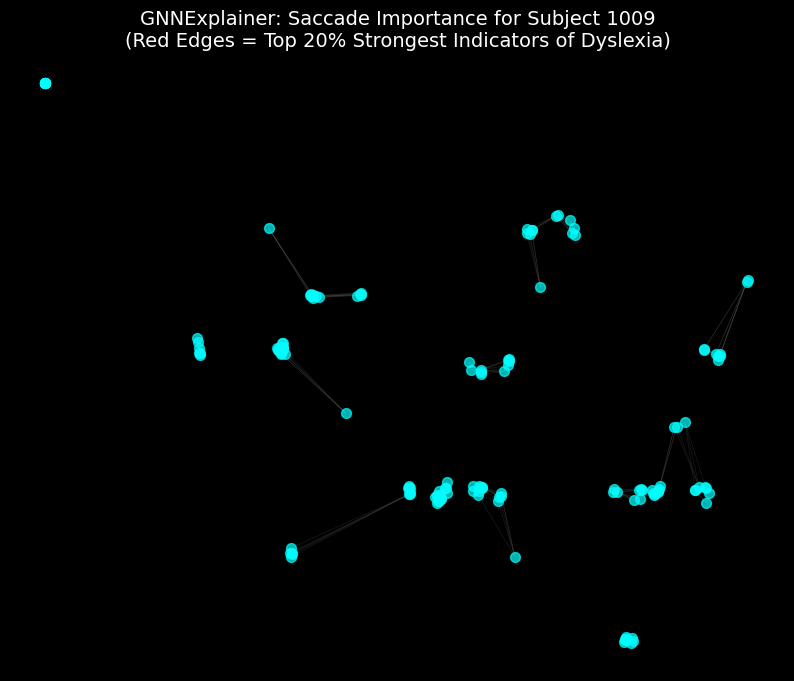

In [19]:
# ════════════════════════════════════════════════════════════════
#  EXPLAINABLE AI: GNNExplainer (Visualizing Diagnostic Features)
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.utils import to_networkx

print(f"{'='*65}")
print("  STARTING GNN EXPLAINER")
print(f"{'='*65}\n")

# 1. Setup the Explainer for your trained GNN
explainer = Explainer(
    model=model_gnn,
    algorithm=GNNExplainer(epochs=200), # Trains a mask for 200 epochs to find the best explanation
    explanation_type='model',
    edge_mask_type='object',
    node_mask_type='attributes',
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw', # Assuming your model outputs raw logits before Softmax
    ),
)

# 2. Pick a subject to explain
# Let's find a Dyslexic subject (Class 1) that the model got highly correct
target_subject_idx = None
for idx, data in enumerate(data_list):
    if subject_labels[SUBJECT_IDS[idx]] == 1: # Find a dyslexic subject
        target_subject_idx = idx
        break

if target_subject_idx is not None:
    print(f"Generating explanation for Subject ID: {SUBJECT_IDS[target_subject_idx]}")

    # Extract the single graph
    graph = data_list[target_subject_idx].to(device)

    # GNNs expect a batch vector. Since it's 1 graph, it's just an array of zeros.
    batch_vector = torch.zeros(graph.x.size(0), dtype=torch.long, device=device)

    # 3. Generate the Explanation
    # We ask it to explain why it chose Class 1 (target=1)
    explanation = explainer(graph.x, graph.edge_index, target=1, batch=batch_vector)

    # 4. Extract the edge importance weights
    edge_mask = explanation.edge_mask.cpu().detach().numpy()

    # NEW: Dynamically normalize the weights so the max weight is always 1.0
    max_weight = edge_mask.max()
    normalized_weights = edge_mask / (max_weight + 1e-10)

    # 5. Visualize the Graph
    # Convert PyG graph to NetworkX for drawing
    G = to_networkx(graph, to_undirected=True)

    plt.figure(figsize=(10, 8))
    plt.title(f"GNNExplainer: Saccade Importance for Subject {SUBJECT_IDS[target_subject_idx]}\n(Red Edges = Top 20% Strongest Indicators of Dyslexia)", fontsize=14, color='white')

    pos = {i: (graph.x[i, 0].item(), -graph.x[i, 1].item()) for i in range(graph.num_nodes)}

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color='cyan', alpha=0.7)

    # Draw edges with dynamic weights
    for i, (u, v) in enumerate(G.edges()):
        weight = normalized_weights[i]

        # Now we highlight the top 20% most important edges for THIS specific subject
        if weight > 0.8:
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=weight*4, alpha=weight, edge_color='red')
        else:
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=0.5, alpha=0.2, edge_color='gray')

    plt.gca().set_facecolor('black')
    plt.gcf().patch.set_facecolor('black')
    plt.axis('off')
    plt.show()

### Inference (with indonesian subject)

In [21]:
TOBII_TSV_PATH = "/content/drive/MyDrive/TA_Project/dataset/pilot_study Data export_9.1.2025.xlsx"

In [22]:
# ════════════════════════════════════════════════════════════════
#  CELL 2 — TOBII PARSER (TSV / XLSX, MULTI-PARTICIPANT)
#
#  Bisa baca:
#   - .tsv (single participant)
#   - .xlsx (single ATAU multi-participant)
#
#  Returns:
#    all_subjects : dict {participant_name: (raw_df, fix_df)}
#                   Berisi semua peserta di file
#    raw_df, fix_df, subject_id : peserta PERTAMA (untuk backward compat)
# ════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')


def _load_tobii_file(filepath):
    """Read TSV or XLSX into a single DataFrame."""
    ext = os.path.splitext(filepath)[1].lower()

    if ext in ('.xlsx', '.xlsm'):
        df = pd.read_excel(filepath, sheet_name=0)
    else:
        # TSV / CSV
        with open(filepath, 'r', encoding='utf-8-sig') as f:
            header_line = f.readline()
        sep = ';' if ';' in header_line else '\t'
        df = pd.read_csv(
            filepath, sep=sep, low_memory=False,
            decimal=',', on_bad_lines='skip',
        )

    df.columns = df.columns.str.strip()
    return df


def _parse_one_participant(df, subject_id, screen_w, screen_h):
    """Parse one participant's rows into (raw_df, fix_df)."""

    def find_col(*keywords):
        for col in df.columns:
            if all(k.lower() in col.lower() for k in keywords):
                return col
        return None

    def to_float_col(col_name):
        s = df[col_name].copy()
        if s.dtype == object:
            s = s.str.replace(',', '.', regex=False)
        return pd.to_numeric(s, errors='coerce')

    # ── Gaze columns ─────────────────────────────────────────────
    lx_col = find_col('gaze point left',  'x', 'dacs px') or find_col('left', 'x')
    rx_col = find_col('gaze point right', 'x', 'dacs px') or find_col('right', 'x')
    ly_col = find_col('gaze point left',  'y', 'dacs px') or find_col('left', 'y')
    ry_col = find_col('gaze point right', 'y', 'dacs px') or find_col('right', 'y')
    ts_col = find_col('recording timestamp') or find_col('timestamp')

    raw_df = pd.DataFrame({
        'gaze_x_left' : to_float_col(lx_col),
        'gaze_x_right': to_float_col(rx_col),
        'gaze_y_left' : to_float_col(ly_col),
        'gaze_y_right': to_float_col(ry_col),
    })

    # ── [PERUBAHAN 1] Timestamp Normalization untuk 60Hz ─────────
    if ts_col:
        ts = to_float_col(ts_col)
        raw_df['timestamp'] = ts - ts.min()

        # Deteksi jika satuan masih Microseconds (nilai max > 1 juta)
        if raw_df['timestamp'].max() > 1000000:
            raw_df['timestamp'] = raw_df['timestamp'] / 1000.0
    else:
        # Fallback jika timestamp tidak ada: Asumsikan 60Hz (1000ms / 60 = ~16.66 ms)
        raw_df['timestamp'] = np.arange(len(raw_df)) * (1000.0 / 60.0)

    # ── Clip raw gaze to screen bounds ───────────────────────────
    raw_df['gaze_x_left']  = raw_df['gaze_x_left'].clip(0, screen_w)
    raw_df['gaze_x_right'] = raw_df['gaze_x_right'].clip(0, screen_w)
    raw_df['gaze_y_left']  = raw_df['gaze_y_left'].clip(0, screen_h)
    raw_df['gaze_y_right'] = raw_df['gaze_y_right'].clip(0, screen_h)
    raw_df['avg_x'] = raw_df[['gaze_x_left', 'gaze_x_right']].mean(axis=1)
    raw_df['avg_y'] = raw_df[['gaze_y_left', 'gaze_y_right']].mean(axis=1)

    # ── [PERUBAHAN 2] Data Imputation untuk Mencegah OOD ─────────
    # Ubah nilai 0.0 atau -1.0 (indikator alat error) menjadi NaN
    raw_df['avg_x'] = raw_df['avg_x'].replace([0.0, -1.0], np.nan)
    raw_df['avg_y'] = raw_df['avg_y'].replace([0.0, -1.0], np.nan)

    # Interpolasi kedipan pendek (limit 5 baris di 60Hz = ~83 ms)
    raw_df['avg_x'] = raw_df['avg_x'].interpolate(method='linear', limit=5)
    raw_df['avg_y'] = raw_df['avg_y'].interpolate(method='linear', limit=5)

    # Buang sisa NaN (kedipan panjang) agar tidak merusak graf GCN & gambar ResNet
    raw_df = raw_df.dropna(subset=['avg_x', 'avg_y']).reset_index(drop=True)
    # ─────────────────────────────────────────────────────────────

    # ── Fixation columns ─────────────────────────────────────────
    evt_col     = find_col('eye movement type')
    dur_col     = find_col('eye movement event duration')
    fix_x_col   = find_col('fixation point x')
    fix_y_col   = find_col('fixation point y')
    fix_idx_col = find_col('eye movement type index')

    if evt_col and fix_x_col:
        fix_mask = df[evt_col].astype(str).str.strip().str.lower() == 'fixation'
        fix_rows = df[fix_mask].copy()

        if fix_idx_col:
            fix_rows = fix_rows.drop_duplicates(subset=[fix_idx_col], keep='first')
        else:
            fix_rows = fix_rows.drop_duplicates(
                subset=[fix_x_col, fix_y_col] + ([dur_col] if dur_col else []),
                keep='first'
            )

        fix_df = pd.DataFrame({
            'fix_x'      : to_float_col(fix_x_col).reindex(fix_rows.index).values,
            'fix_y'      : to_float_col(fix_y_col).reindex(fix_rows.index).values,
        })
        fix_df['start_ms'] = (to_float_col(ts_col).reindex(fix_rows.index).values
                              if ts_col else np.zeros(len(fix_rows)))
        if dur_col:
            durs = pd.to_numeric(
                fix_rows[dur_col].astype(str).str.replace(',', '.', regex=False),
                errors='coerce'
            ).values
            fix_df['duration_ms'] = durs
        else:
            fix_df['duration_ms'] = 150.0

        fix_df['end_ms'] = fix_df['start_ms'] + fix_df['duration_ms']
        fix_df['seq']    = np.arange(len(fix_df), dtype=float)
        fix_df = fix_df.dropna(subset=['fix_x', 'fix_y']).reset_index(drop=True)
    else:
        print(f"  ⚠ [{subject_id}] No 'Eye movement type' column. Using fallback.")
        x = raw_df['avg_x'].rolling(10, center=True).median()
        y = raw_df['avg_y'].rolling(10, center=True).median()
        ts_arr = raw_df['timestamp'].values
        x_clean = x.dropna().values[::10]
        y_clean = y.dropna().values[::10]
        n = min(len(x_clean), len(y_clean))
        fix_df = pd.DataFrame({
            'fix_x'      : x_clean[:n],
            'fix_y'      : y_clean[:n],
            'start_ms'   : ts_arr[::10][:n],
            'duration_ms': np.full(n, 150.0),
        })
        fix_df['end_ms'] = fix_df['start_ms'] + fix_df['duration_ms']
        fix_df['seq']    = np.arange(len(fix_df), dtype=float)

    # GARANSI: pastikan kolom yang diperlukan selalu ada, bahkan untuk DataFrame kosong
    for col, default_dtype in [('fix_x', float), ('fix_y', float),
                                ('start_ms', float), ('duration_ms', float),
                                ('end_ms', float), ('seq', float)]:
        if col not in fix_df.columns:
            fix_df[col] = pd.Series(dtype=default_dtype)

    if len(fix_df) > 0:
        fix_df['fix_x'] = fix_df['fix_x'].clip(0, screen_w)
        fix_df['fix_y'] = fix_df['fix_y'].clip(0, screen_h)

    return raw_df, fix_df


def parse_tobii_file(filepath, screen_w=SCREEN_W, screen_h=SCREEN_H,
                     subject_id_override=None):
    """
    Parse a Tobii export (.tsv or .xlsx). Supports multi-participant files.

    Returns
    -------
    all_subjects : dict {participant_name: (raw_df, fix_df)}
    """
    print(f"Reading {os.path.basename(filepath)} ...")
    df_full = _load_tobii_file(filepath)
    print(f"  Total rows: {len(df_full):,}")

    # ── Detect participants ─────────────────────────────────────
    if 'Participant name' in df_full.columns:
        participants = df_full['Participant name'].dropna().unique().tolist()
    else:
        participants = [subject_id_override or
                        os.path.splitext(os.path.basename(filepath))[0]]
        df_full['Participant name'] = participants[0]

    print(f"  Participants found: {len(participants)} → {participants}")

    # ── Parse each participant ──────────────────────────────────
    all_subjects = {}
    for pname in participants:
        sub_df = df_full[df_full['Participant name'] == pname].reset_index(drop=True)
        print(f"\n  Parsing [{pname}] : {len(sub_df):,} rows")
        raw, fix = _parse_one_participant(sub_df, str(pname), screen_w, screen_h)
        print(f"    → {len(raw):,} gaze samples, {len(fix)} fixations")
        all_subjects[str(pname)] = (raw, fix)

    return all_subjects


# ── Run parser ────────────────────────────────────────────────────
all_subjects = parse_tobii_file(TOBII_TSV_PATH)

# Backward-compat: ambil peserta pertama untuk Cell 3/4 yang sudah ada
subject_id = list(all_subjects.keys())[0]
raw_df, fix_df = all_subjects[subject_id]

print(f"\n{'='*60}")
print(f"Loaded {len(all_subjects)} participant(s).")
print(f"Default subject for Cell 3/4 : {subject_id}")
print(f"Gaze samples : {len(raw_df):,}")
print(f"Fixations    : {len(fix_df)}")
print()
print(fix_df.head(5).to_string(index=False))

Reading pilot_study Data export_9.1.2025.xlsx ...
  Total rows: 305,719
  Participants found: 21 → ['Gibran', 'Nadine2', 'P4 (Athaya)', 'P5 (Elmayka)', 'Nadine', 'Test', 'P2 Aleshaa', 'aleesha 2', 'P3 (RAZZAKA)', 'p2 (aleesha 2)', 'p (6) abiyu', 'P7 (saki)', 'P8 (Nabil)', 'P9 (Sabria)', 'p10 (Khalifi)', 'Mateo', 'Allen', 'Ragheeb', 'ayas', 'rafka', 'lion']

  Parsing [Gibran] : 11,727 rows
    → 11,054 gaze samples, 562 fixations

  Parsing [Nadine2] : 10,510 rows
    → 9,574 gaze samples, 410 fixations

  Parsing [P4 (Athaya)] : 20,874 rows
    → 18,833 gaze samples, 847 fixations

  Parsing [P5 (Elmayka)] : 15,615 rows
    → 13,566 gaze samples, 517 fixations

  Parsing [Nadine] : 19,939 rows
    → 13,609 gaze samples, 732 fixations

  Parsing [Test] : 5,659 rows
    → 3,259 gaze samples, 106 fixations

  Parsing [P2 Aleshaa] : 15,525 rows
    → 10,577 gaze samples, 377 fixations

  Parsing [aleesha 2] : 25,198 rows
    → 3,800 gaze samples, 68 fixations

  Parsing [P3 (RAZZAKA)] : 8

In [23]:
# ════════════════════════════════════════════════════════════════
#  CELL 1 — CONFIG
#  Edit these paths/settings before running.
# ════════════════════════════════════════════════════════════════

import os

TOBII_TSV_PATH = "/content/drive/MyDrive/TA_Project/dataset/dataset.csv"

SUBJECT_ID_OVERRIDE = "Mira Suryani"

SCREEN_W = 1680
SCREEN_H = 1050

GCN_WEIGHTS_PATTERN = "gcn_weights_fold_{fold}.pth"   # relative to cwd
RESNET_WEIGHTS_PATTERN = "resnet_weights_fold_{fold}.pth"
FORCE_FOLD = None

MAX_FIXATIONS = 150
K_NEIGHBORS   = 5
GNN_HIDDEN    = 64
NODE_FEATS    = 4

ABSTENTION_THRESHOLD = 0.5
INFERENCE_THRESHOLD  = 0.47
INFER_W_RES = 0.5
INFER_W_GCN = 0.5

print("Config OK")

Config OK


In [24]:
# ════════════════════════════════════════════════════════════════
#  CELL 3 — BUILD RESNET INPUT + GCN GRAPH
#  Converts parsed data into:
#    mira_img_tensor  : (1, 3, 224, 224)  – for ResNet
#    mira_graph_data  : torch_geometric.data.Data  – for GCN
# ════════════════════════════════════════════════════════════════

import io
import numpy as np
import torch
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from PIL import Image
from torchvision import transforms as tv_transforms
from torch_geometric.data import Data

# ── 1. SCANPATH IMAGE → ResNet tensor ────────────────────────────
def build_scanpath_image(fix_df, screen_w, screen_h):
    """
    Render a scanpath image from fixation table (same logic as _render_images).
    Returns a PIL Image (RGB).
    """
    x = fix_df["fix_x"].values.astype(float)
    y = fix_df["fix_y"].values.astype(float)

    valid = ~(np.isnan(x) | np.isnan(y))
    x, y  = x[valid], y[valid]

    fig, ax = plt.subplots(figsize=(screen_w / 100, screen_h / 100), dpi=100)
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    ax.set_xlim(0, screen_w)
    ax.set_ylim(screen_h, 0)
    ax.axis("off")

    # [PERBAIKAN 1]: Hapus SEMUA margin agar gambar murni hitam untuk ResNet
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
    plt.margins(0,0)
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    if len(x) >= 2:
        points   = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        dx       = np.diff(x)
        colors = [(1.0, 0.0, 0.0, 0.9) if delta < -5 else (0.0, 0.0, 0.0, 0.0) for delta in dx]
        ax.add_collection(LineCollection(segments, colors=colors, linewidths=3))

    ax.scatter(x, y, color="white", s=8, alpha=0.15, zorder=3)

    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight",
                pad_inches=0, facecolor="black")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

# Apply the same transform used during training
infer_tf = tv_transforms.Compose([
    tv_transforms.Resize((224, 224)),
    tv_transforms.ToTensor(),
    tv_transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── 2. FIXATION GRAPH → GCN Data (DARI RAW_DF) ───────────────────
def build_graph_from_rawdf(raw_df, max_fixations=150, k_neighbors=5, screen_w=1680, screen_h=1050):
    fixation_min_pts = 2
    FIXATION_MAX_DISP = 3.5   # Boleh dilonggarkan untuk meredam jitter kamera
    PX_PER_DEG = 37.44

    x  = raw_df["avg_x"].values
    y  = raw_df["avg_y"].values

    # Kita tidak lagi butuh ts untuk menghitung durasi karena kita akan memaksanya ke 20ms
    fixations = []
    i = 0
    while i < len(x) - fixation_min_pts:
        wx = x[i : i + fixation_min_pts]
        wy = y[i : i + fixation_min_pts]
        if (np.nanmax(wx) - np.nanmin(wx) <= FIXATION_MAX_DISP * PX_PER_DEG and
            np.nanmax(wy) - np.nanmin(wy) <= FIXATION_MAX_DISP * PX_PER_DEG):
            cx  = np.nanmean(wx)
            cy  = np.nanmean(wy)

            # HACK: Paksa durasi persis 20.0 ms seperti saat training ETDD70
            dur = 20.0

            fixations.append([cx, cy, dur, float(len(fixations))])
            i += fixation_min_pts
        else:
            i += 1

    nodes = np.array(fixations) if fixations else np.zeros((1, 4))

    # Cap nodes
    if len(nodes) > max_fixations:
        # Karena durasi semua 20, kita ambil berdasarkan urutan saja
        nodes = nodes[:max_fixations]

    # Normalisasi identik dengan training
    nodes[:, 0] /= (screen_w + 1e-6)
    nodes[:, 1] /= (screen_h + 1e-6)
    nodes[:, 2] = np.log1p(nodes[:, 2]) # Ini akan selalu menghasilkan ~3.04
    nodes[:, 3] /= (len(nodes) + 1e-6)

    # Edges
    F = len(nodes)
    k = min(k_neighbors, F - 1)
    if k <= 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    else:
        coords = nodes[:, :2]
        diff = coords[:, None, :] - coords[None, :, :]
        dist = np.linalg.norm(diff, axis=-1)
        np.fill_diagonal(dist, np.inf)
        nn_idx = np.argsort(dist, axis=1)[:, :k]
        src = np.repeat(np.arange(F), k)
        dst = nn_idx.reshape(-1)
        edge_index = np.unique(np.stack([np.concatenate([src, dst]), np.concatenate([dst, src])], axis=0), axis=1)
        edge_index = torch.tensor(edge_index, dtype=torch.long)

    node_feats = torch.tensor(nodes, dtype=torch.float32)
    batch = torch.zeros(F, dtype=torch.long)
    return Data(x=node_feats, edge_index=edge_index, batch=batch)

MIRA_MAX_FIX = min(len(fix_df), 300)

# ── Clean fix_df before passing to ResNet ──────────────────────────
fix_df_clean = fix_df.copy()

# 1. Clip coordinates to screen bounds
fix_df_clean['fix_x'] = fix_df_clean['fix_x'].clip(0, SCREEN_W)
fix_df_clean['fix_y'] = fix_df_clean['fix_y'].clip(0, SCREEN_H)

# 2. Cap to same MAX_FIXATIONS used during training (150)
if len(fix_df_clean) > MAX_FIXATIONS:
    fix_df_clean = (fix_df_clean
                    .nlargest(MAX_FIXATIONS, 'duration_ms')
                    .sort_values('seq')
                    .reset_index(drop=True))
    fix_df_clean['seq'] = np.arange(len(fix_df_clean), dtype=float)

print(f"fix_df after cleaning : {len(fix_df_clean)} fixations")
if len(fix_df_clean) > 0:
    print(f"fix_x range : {fix_df_clean['fix_x'].min():.0f} – {fix_df_clean['fix_x'].max():.0f}")
    print(f"fix_y range : {fix_df_clean['fix_y'].min():.0f} – {fix_df_clean['fix_y'].max():.0f}")

# 3. Rebuild graph and image from cleaned data
# ResNet menggunakan fix_df_clean
pil_img = build_scanpath_image(fix_df_clean, SCREEN_W, SCREEN_H)
mira_img_tensor = infer_tf(pil_img)

# [PERBAIKAN 3]: GCN WAJIB menggunakan raw_df, bukan fix_df_clean!
mira_graph_data = build_graph_from_rawdf(
    raw_df,  # Memanggil raw_df dari hasil output Cell 2
    max_fixations=MAX_FIXATIONS,
    k_neighbors=K_NEIGHBORS,
    screen_w=SCREEN_W,
    screen_h=SCREEN_H,
)

print(f"\nScanpath image size : {pil_img.size[0]}×{pil_img.size[1]} px")
print(f"ResNet input tensor : {tuple(mira_img_tensor.shape)}")
print(f"GCN graph           : {mira_graph_data.x.shape[0]} nodes, "
      f"{mira_graph_data.edge_index.shape[1]} edges")

# Verify node features are now in range
print(f"\nNode feature check:")
print(f"  cx_norm : {mira_graph_data.x[:, 0].min():.3f} – {mira_graph_data.x[:, 0].max():.3f}  (expect 0–1)")
print(f"  cy_norm : {mira_graph_data.x[:, 1].min():.3f} – {mira_graph_data.x[:, 1].max():.3f}  (expect 0–1)")
print(f"  dur_norm: {mira_graph_data.x[:, 2].min():.3f} – {mira_graph_data.x[:, 2].max():.3f}  (expect ~3 to ~8 maximum)")
print("Cell 3 complete ✓")


# ════════════════════════════════════════════════════════════════
#  CELL 4 — ENSEMBLE INFERENCE FOR MIRA SURYANI
#  Requires: infer_resnet, infer_gcn, INFER_W_RES, INFER_W_GCN,
#             ABSTENTION_THRESHOLD, INFERENCE_THRESHOLD (from main nb)
# ════════════════════════════════════════════════════════════════

import torch.nn.functional as F

# ── Forward pass ─────────────────────────────────────────────────
infer_resnet.eval()
infer_gcn.eval()

with torch.no_grad():
    # ResNet
    img_input = mira_img_tensor.unsqueeze(0).to(device)   # (1,3,224,224)
    res_logits = infer_resnet(img_input)
    res_prob   = F.softmax(res_logits, dim=1)[0, 1].item()

    # GCN
    gd = mira_graph_data.to(device)
    gcn_logits = infer_gcn(gd.x, gd.edge_index, gd.batch)
    gcn_prob   = F.softmax(gcn_logits, dim=1)[0, 1].item()

# ── Abstention + ensemble blend ───────────────────────────────────
if res_prob < ABSTENTION_THRESHOLD:
    ens_prob  = gcn_prob
    abstained = True
else:
    ens_prob  = INFER_W_RES * res_prob + INFER_W_GCN * gcn_prob
    abstained = False

prediction = int(ens_prob >= INFERENCE_THRESHOLD)
label_str  = "DYSLEXIC" if prediction == 1 else "CONTROL"
confidence = ens_prob if prediction == 1 else (1.0 - ens_prob)

# ── Print result ──────────────────────────────────────────────────
print("=" * 60)
print(f"  INFERENCE RESULT  —  {subject_id}")
print("=" * 60)
print(f"  ResNet probability  : {res_prob*100:6.2f}%")
print(f"  GCN    probability  : {gcn_prob*100:6.2f}%")
print(f"  Ensemble probability: {ens_prob*100:6.2f}%")
print(f"  Abstained (GCN-only): {'YES ⚠' if abstained else 'No'}")
print(f"  Threshold used      : {INFERENCE_THRESHOLD:.2f}")
print(f"  Weights  res/gcn    : {INFER_W_RES:.3f} / {INFER_W_GCN:.3f}")
print("-" * 60)
print(f"  ▶  PREDICTION : {label_str}")
print(f"  ▶  CONFIDENCE : {confidence*100:.1f}%")
print("=" * 60)

# ── Optional: visualise the scanpath that was fed to ResNet ───────
fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(pil_img)
ax.set_title(
    f"{subject_id}  →  {label_str}  ({confidence*100:.1f}%)\n"
    f"ResNet {res_prob*100:.1f}%  |  GCN {gcn_prob*100:.1f}%  |  "
    f"Ens {ens_prob*100:.1f}%"
    + ("  [ABSTAINED]" if abstained else ""),
    fontsize=10, color="white"
)
fig.patch.set_facecolor("#111")
ax.axis("off")
plt.tight_layout()
plt.show()

fix_df after cleaning : 150 fixations
fix_x range : 140 – 1680
fix_y range : 265 – 1050

Scanpath image size : 1680×1050 px
ResNet input tensor : (3, 224, 224)
GCN graph           : 150 nodes, 988 edges

Node feature check:
  cx_norm : 0.572 – 0.814  (expect 0–1)
  cy_norm : 0.243 – 0.756  (expect 0–1)
  dur_norm: 3.045 – 3.045  (expect ~3 to ~8 maximum)
Cell 3 complete ✓


NameError: name 'infer_resnet' is not defined

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 5 — BATCH INFERENCE UNTUK SEMUA SUBJEK
# ════════════════════════════════════════════════════════════════
import pandas as pd
import torch
import torch.nn.functional as F

print("Memulai Batch Inference untuk 21 Subjek...\n")
print("-" * 85)
print(f"{'SUBJECT ID':<18} | {'RESNET (%)':<12} | {'GCN (%)':<10} | {'ENSEMBLE (%)':<14} | {'PREDICTION'}")
print("-" * 85)

hasil_rekap = []

# Pastikan model dalam mode evaluasi
infer_resnet.eval()
infer_gcn.eval()

for subj_name, (r_df, f_df) in all_subjects.items():
    try:
        # 1. Clean Fixation Data (untuk ResNet)
        f_clean = f_df.copy()
        f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
        f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)

        if len(f_clean) > MAX_FIXATIONS:
            f_clean = (f_clean.nlargest(MAX_FIXATIONS, 'duration_ms')
                              .sort_values('seq').reset_index(drop=True))
            f_clean['seq'] = np.arange(len(f_clean), dtype=float)

        # Lewati jika data kosong (error dari alat)
        if len(f_clean) < 2 or len(r_df) < 10:
            print(f"{subj_name:<18} | DATA TERLALU SEDIKIT / ERROR")
            continue

        # 2. Build Inputs
        pil_img = build_scanpath_image(f_clean, SCREEN_W, SCREEN_H)
        img_tensor = infer_tf(pil_img).unsqueeze(0).to(device)

        # PENTING: Gunakan raw_df untuk GCN
        graph_data = build_graph_from_rawdf(r_df, max_fixations=MAX_FIXATIONS,
                                            k_neighbors=K_NEIGHBORS,
                                            screen_w=SCREEN_W, screen_h=SCREEN_H).to(device)

        # 3. Forward Pass
        # 3. Forward Pass
        with torch.no_grad():
            res_logits = infer_resnet(img_tensor)
            res_prob   = F.softmax(res_logits, dim=1)[0, 1].item()

            # Matikan GCN, kita pakai ResNet saja
            ens_prob = res_prob

        # Gunakan Threshold standar 50% (0.50)
        prediction = "DYSLEXIC" if ens_prob >= 0.50 else "CONTROL"

        # 4. Hitung Ensemble
        if res_prob < ABSTENTION_THRESHOLD:
            ens_prob = gcn_prob
            abstained = True
        else:
            ens_prob = INFER_W_RES * res_prob + INFER_W_GCN * gcn_prob
            abstained = False

        prediction = "DYSLEXIC" if ens_prob >= INFERENCE_THRESHOLD else "CONTROL"

        # Simpan ke list
        hasil_rekap.append({
            'Subject': subj_name,
            'ResNet_Prob': res_prob,
            'GCN_Prob': gcn_prob,
            'Ensemble_Prob': ens_prob,
            'Abstained': abstained,
            'Prediction': prediction
        })

        # Cetak baris per baris
        tanda_abstain = "⚠ " if abstained else "  "
        print(f"{subj_name:<18} | {res_prob*100:>8.1f}%    | {gcn_prob*100:>7.1f}% {tanda_abstain}| {ens_prob*100:>10.1f}%    |  {prediction}")

    except Exception as e:
        print(f"{subj_name:<18} | ERROR: {str(e)[:30]}")

print("-" * 85)

# 5. Tampilkan DataFrame Rekapitulasi Akhir
df_hasil = pd.DataFrame(hasil_rekap)

total_dyslexic = len(df_hasil[df_hasil['Prediction'] == 'DYSLEXIC'])
total_control = len(df_hasil[df_hasil['Prediction'] == 'CONTROL'])

print(f"\nRINGKASAN AKHIR:")
print(f"Total Subjek Berhasil   : {len(df_hasil)}")
print(f"Terdeteksi DYSLEXIC     : {total_dyslexic} orang")
print(f"Terdeteksi CONTROL      : {total_control} orang")

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 5 — BATCH INFERENCE UNTUK SEMUA SUBJEK
# ════════════════════════════════════════════════════════════════
import pandas as pd
import torch
import torch.nn.functional as F

print("Memulai Batch Inference untuk 21 Subjek...\n")
print("-" * 85)
print(f"{'SUBJECT ID':<18} | {'RESNET (%)':<12} | {'GCN (%)':<10} | {'ENSEMBLE (%)':<14} | {'PREDICTION'}")
print("-" * 85)

hasil_rekap = []

# Pastikan model dalam mode evaluasi
infer_resnet.eval()
infer_gcn.eval()

for subj_name, (r_df, f_df) in all_subjects.items():
    try:
        # 1. Clean Fixation Data (untuk ResNet)
        f_clean = f_df.copy()
        f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
        f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)

        if len(f_clean) > MAX_FIXATIONS:
            f_clean = (f_clean.nlargest(MAX_FIXATIONS, 'duration_ms')
                              .sort_values('seq').reset_index(drop=True))
            f_clean['seq'] = np.arange(len(f_clean), dtype=float)

        # Lewati jika data kosong (error dari alat)
        if len(f_clean) < 2 or len(r_df) < 10:
            print(f"{subj_name:<18} | DATA TERLALU SEDIKIT / ERROR")
            continue

        # 2. Build Inputs
        pil_img = build_scanpath_image(f_clean, SCREEN_W, SCREEN_H)
        img_tensor = infer_tf(pil_img).unsqueeze(0).to(device)

        # PENTING: Gunakan raw_df untuk GCN
        graph_data = build_graph_from_rawdf(r_df, max_fixations=MAX_FIXATIONS,
                                            k_neighbors=K_NEIGHBORS,
                                            screen_w=SCREEN_W, screen_h=SCREEN_H).to(device)

        # 3. Forward Pass
        # 3. Forward Pass
        infer_effnet.eval()
        with torch.no_grad():
            eff_logits = infer_effnet(img_tensor)
            res_prob   = F.softmax(eff_logits, dim=1)[0, 1].item()

            # Matikan GCN, kita pakai ResNet saja
            ens_prob = res_prob

        # Gunakan Threshold standar 50% (0.50)
        prediction = "DYSLEXIC" if ens_prob >= 0.50 else "CONTROL"

        # 4. Hitung Ensemble
        if res_prob < ABSTENTION_THRESHOLD:
            ens_prob = gcn_prob
            abstained = True
        else:
            ens_prob = INFER_W_RES * res_prob + INFER_W_GCN * gcn_prob
            abstained = False

        prediction = "DYSLEXIC" if ens_prob >= INFERENCE_THRESHOLD else "CONTROL"

        # Simpan ke list
        hasil_rekap.append({
            'Subject': subj_name,
            'ResNet_Prob': res_prob,
            'GCN_Prob': gcn_prob,
            'Ensemble_Prob': ens_prob,
            'Abstained': abstained,
            'Prediction': prediction
        })

        # Cetak baris per baris
        tanda_abstain = "⚠ " if abstained else "  "
        print(f"{subj_name:<18} | {res_prob*100:>8.1f}%    | {gcn_prob*100:>7.1f}% {tanda_abstain}| {ens_prob*100:>10.1f}%    |  {prediction}")

    except Exception as e:
        print(f"{subj_name:<18} | ERROR: {str(e)[:30]}")

print("-" * 85)

# 5. Tampilkan DataFrame Rekapitulasi Akhir
df_hasil = pd.DataFrame(hasil_rekap)

total_dyslexic = len(df_hasil[df_hasil['Prediction'] == 'DYSLEXIC'])
total_control = len(df_hasil[df_hasil['Prediction'] == 'CONTROL'])

print(f"\nRINGKASAN AKHIR:")
print(f"Total Subjek Berhasil   : {len(df_hasil)}")
print(f"Terdeteksi DYSLEXIC     : {total_dyslexic} orang")
print(f"Terdeteksi CONTROL      : {total_control} orang")

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 5 — BATCH INFERENCE (RESNET-ONLY DEBUG MODE)
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import traceback # <--- Tambahkan library ini untuk melacak error

print("Memulai Batch Inference (ResNet-Only) untuk 21 Subjek...\n")
print("-" * 65)
print(f"{'SUBJECT ID':<18} | {'RESNET PROB (%)':<18} | {'PREDICTION'}")
print("-" * 65)

hasil_rekap = []
infer_resnet.eval()

for subj_name, (r_df, f_df) in all_subjects.items():
    try:
        f_clean = f_df.copy()
        f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
        f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)

        if len(f_clean) > MAX_FIXATIONS:
            f_clean = (f_clean.nlargest(MAX_FIXATIONS, 'duration_ms')
                              .sort_values('seq').reset_index(drop=True))
            f_clean['seq'] = np.arange(len(f_clean), dtype=float)

        if len(f_clean) < 2:
            print(f"{subj_name:<18} | DATA TERLALU SEDIKIT / ERROR")
            continue

        # 🎯 Titik kecurigaan: Pastikan build_scanpath_image Anda masih normal
        pil_img = build_scanpath_image(f_clean, SCREEN_W, SCREEN_H)
        img_tensor = infer_tf(pil_img).unsqueeze(0).to(device)

        with torch.no_grad():
            res_logits = infer_resnet(img_tensor)
            res_prob   = F.softmax(res_logits, dim=1)[0, 1].item()

        prediction = "DYSLEXIC" if res_prob >= 0.50 else "CONTROL"

        hasil_rekap.append({
            'Subject': subj_name,
            'ResNet_Prob': res_prob,
            'Prediction': prediction
        })

        print(f"{subj_name:<18} | {res_prob*100:>14.1f}%    |  {prediction}")

    except Exception as e:
        print(f"\n{subj_name:<18} | ERROR TERJADI DI SINI:")
        # Ini akan mencetak file dan baris spesifik penyebab error!
        traceback.print_exc()
        break # Hentikan loop agar layarnya tidak penuh dengan error yang sama

print("-" * 65)

df_hasil = pd.DataFrame(hasil_rekap)

# Pengaman agar tidak KeyError 'Prediction' jika tabel kosong
if len(df_hasil) > 0:
    total_dyslexic = len(df_hasil[df_hasil['Prediction'] == 'DYSLEXIC'])
    total_control = len(df_hasil[df_hasil['Prediction'] == 'CONTROL'])

    print(f"\nRINGKASAN AKHIR (RESNET-ONLY):")
    print(f"Total Subjek Berhasil   : {len(df_hasil)}")
    print(f"Terdeteksi DYSLEXIC     : {total_dyslexic} orang")
    print(f"Terdeteksi CONTROL      : {total_control} orang")
else:
    print("\n⚠️ Tidak ada subjek yang berhasil diproses. Silakan cek pesan error di atas.")

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 5 — BATCH INFERENCE (RESNET-ONLY DEBUG MODE)
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import traceback # <--- Tambahkan library ini untuk melacak error

print("Memulai Batch Inference (EffB0) untuk 21 Subjek...\n")
print("-" * 65)
print(f"{'SUBJECT ID':<18} | {'EffB0 PROB (%)':<18} | {'PREDICTION'}")
print("-" * 65)

hasil_rekap = []
infer_resnet.eval()

for subj_name, (r_df, f_df) in all_subjects.items():
    try:
        f_clean = f_df.copy()
        f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
        f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)

        if len(f_clean) > MAX_FIXATIONS:
            f_clean = (f_clean.nlargest(MAX_FIXATIONS, 'duration_ms')
                              .sort_values('seq').reset_index(drop=True))
            f_clean['seq'] = np.arange(len(f_clean), dtype=float)

        if len(f_clean) < 2:
            print(f"{subj_name:<18} | DATA TERLALU SEDIKIT / ERROR")
            continue

        # 🎯 Titik kecurigaan: Pastikan build_scanpath_image Anda masih normal
        pil_img = build_scanpath_image(f_clean, SCREEN_W, SCREEN_H)
        img_tensor = infer_tf(pil_img).unsqueeze(0).to(device)

        with torch.no_grad():
            eff_logits = infer_effnet(img_tensor)
            res_prob   = F.softmax(eff_logits, dim=1)[0, 1].item()

        prediction = "DYSLEXIC" if res_prob >= 0.50 else "CONTROL"

        hasil_rekap.append({
            'Subject': subj_name,
            'ResNet_Prob': res_prob,
            'Prediction': prediction
        })

        print(f"{subj_name:<18} | {res_prob*100:>14.1f}%    |  {prediction}")

    except Exception as e:
        print(f"\n{subj_name:<18} | ERROR TERJADI DI SINI:")
        # Ini akan mencetak file dan baris spesifik penyebab error!
        traceback.print_exc()
        break # Hentikan loop agar layarnya tidak penuh dengan error yang sama

print("-" * 65)

df_hasil = pd.DataFrame(hasil_rekap)

# Pengaman agar tidak KeyError 'Prediction' jika tabel kosong
if len(df_hasil) > 0:
    total_dyslexic = len(df_hasil[df_hasil['Prediction'] == 'DYSLEXIC'])
    total_control = len(df_hasil[df_hasil['Prediction'] == 'CONTROL'])

    print(f"\nRINGKASAN AKHIR (RESNET-ONLY):")
    print(f"Total Subjek Berhasil   : {len(df_hasil)}")
    print(f"Terdeteksi DYSLEXIC     : {total_dyslexic} orang")
    print(f"Terdeteksi CONTROL      : {total_control} orang")
else:
    print("\n⚠️ Tidak ada subjek yang berhasil diproses. Silakan cek pesan error di atas.")

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 6 — LEAVE-ONE-OUT CROSS-VALIDATION (EFF-B0 FINE-TUNING)
#  Subset: 3 Dyslexic vs 3 Control
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torchvision import models as tv_models
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from copy import deepcopy

print("Mempersiapkan Data 6 Subjek Fokus...\n")

# 1. Kunci Jawaban (Ground Truth) untuk 6 Subjek Pilihan Anda
# focused_labels = {
#     'Ragheeb': 1,      # Dyslexic
#     'ayas': 1,         # Dyslexic
#     'aleesha 2': 1,    # Dyslexic (Menggunakan sesi aleesha 2)
#     'P4 (Athaya)': 0,  # Control
#     'P5 (Elmayka)': 0, # Control
#     'p (6) abiyu': 0   # Control
# }

focused_labels = {
    'Ragheeb': 1,      # Dyslexic
    'ayas': 1,         # Dyslexic
    'aleesha 2': 1,    # Dyslexic
    'P7 (saki)': 0,  # Control
    'P8 (Nabil)': 0, # Control
    'P9 (Sabria)': 0   # Control
}

# 2. Ekstrak dan Generate Gambar (Hanya 1 kali di awal agar cepat)
dataset_cache = {}
for subj, label in focused_labels.items():
    if subj not in all_subjects:
        print(f"⚠️ Peringatan: Data '{subj}' tidak ditemukan di all_subjects!")
        continue

    r_df, f_df = all_subjects[subj]
    f_clean = f_df.copy()
    f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
    f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)
    if len(f_clean) > MAX_FIXATIONS:
        f_clean = f_clean.nlargest(MAX_FIXATIONS, 'duration_ms').sort_values('seq').reset_index(drop=True)

    pil_img = build_scanpath_image(f_clean, SCREEN_W, SCREEN_H)
    dataset_cache[subj] = {'image': pil_img, 'label': label}

print(f"✅ Berhasil memproses {len(dataset_cache)} gambar subjek.")

# 3. Setup Dataset & Augmentasi PyTorch
class ScanpathDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, idx):
        item = self.data_list[idx]
        img = item['image']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(item['label'], dtype=torch.long)

# Augmentasi ekstrem untuk mencegah Overfitting karena data sangat sedikit
train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# 4. Fungsi Pembuat Model Fresh
def get_fresh_model():
    model = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.DEFAULT)
    # Freeze semua layer (biarkan ia menggunakan memori bentuk garis pre-trained)
    for param in model.parameters():
        param.requires_grad = False
    # Ganti & Unfreeze layer terakhir saja (untuk klasifikasi Control vs Dyslexic)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5, inplace=True),
        nn.Linear(in_features, 2),
    )
    return model.to(device)

# 5. Eksekusi LOOCV (Mulai Putaran)
print("\n" + "="*65)
print(f"{'SUBJECT DIUJI':<15} | {'TRUE LABEL':<12} | {'PREDIKSI':<12} | {'EFF-B0 PROB'}")
print("="*65)

EPOCHS = 19 # Karena fine-tuning layar akhir, 15 epoch cukup
loocv_results = []

for test_subject in dataset_cache.keys():
    # A. Pisahkan 1 Data Uji dan 5 Data Latih
    test_data = [dataset_cache[test_subject]]
    train_data = [data for name, data in dataset_cache.items() if name != test_subject]

    train_ds = ScanpathDataset(train_data, transform=train_tf)
    test_ds = ScanpathDataset(test_data, transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=5, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    # B. Panggil Model Baru & Optimizer
    model = get_fresh_model()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.classifier.parameters(), lr=0.005, weight_decay=1e-4)

    # C. Proses Training (5 Subjek)
    model.train()
    for epoch in range(EPOCHS):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # D. Proses Testing (Menebak 1 Subjek Uji)
    model.eval()
    with torch.no_grad():
        test_inputs, test_labels = next(iter(test_loader))
        test_inputs = test_inputs.to(device)

        logits = model(test_inputs)
        prob = F.softmax(logits, dim=1)[0, 1].item()

    pred_label = "DYSLEXIC" if prob >= 0.50 else "CONTROL"
    true_label = "DYSLEXIC" if dataset_cache[test_subject]['label'] == 1 else "CONTROL"
    status = "✅" if pred_label == true_label else "❌"

    loocv_results.append({'Subject': test_subject, 'Status': status})

    print(f"{test_subject:<15} | {true_label:<12} | {pred_label:<12} | {prob*100:>6.1f}% {status}")

# 6. Ringkasan LOOCV
print("="*65)
df_loocv = pd.DataFrame(loocv_results)
akurasi = (len(df_loocv[df_loocv['Status'] == '✅']) / len(df_loocv)) * 100
print(f"AKURASI LOOCV FINAL (6 SUBJEK) : {akurasi:.1f}%")
print("="*65)

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 6 — LEAVE-ONE-OUT CROSS-VALIDATION (RESNET18 FINE-TUNING)
#  Subset: 3 Dyslexic vs 3 Control
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torchvision import models as tv_models
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from copy import deepcopy

print("Mempersiapkan Data 6 Subjek Fokus...\n")

# 1. Kunci Jawaban (Ground Truth) untuk 6 Subjek Pilihan Anda
focused_labels = {
    'Ragheeb': 1,      # Dyslexic
    'ayas': 1,         # Dyslexic
    'aleesha 2': 1,    # Dyslexic (Menggunakan sesi aleesha 2)
    'P4 (Athaya)': 0,  # Control
    'P5 (Elmayka)': 0, # Control
    'p (6) abiyu': 0   # Control
}

# 2. Ekstrak dan Generate Gambar (Hanya 1 kali di awal agar cepat)
dataset_cache = {}
for subj, label in focused_labels.items():
    if subj not in all_subjects:
        print(f"⚠️ Peringatan: Data '{subj}' tidak ditemukan di all_subjects!")
        continue

    r_df, f_df = all_subjects[subj]
    f_clean = f_df.copy()
    f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
    f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)
    if len(f_clean) > MAX_FIXATIONS:
        f_clean = f_clean.nlargest(MAX_FIXATIONS, 'duration_ms').sort_values('seq').reset_index(drop=True)

    pil_img = build_scanpath_image(f_clean, SCREEN_W, SCREEN_H)
    dataset_cache[subj] = {'image': pil_img, 'label': label}

print(f"✅ Berhasil memproses {len(dataset_cache)} gambar subjek.")

# 3. Setup Dataset & Augmentasi PyTorch
class ScanpathDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, idx):
        item = self.data_list[idx]
        img = item['image']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(item['label'], dtype=torch.long)

# Augmentasi gambar untuk mencegah Overfitting
train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# 4. Fungsi Pembuat Model Fresh (Modifikasi untuk ResNet18)
def get_fresh_model():
    # Load ResNet18 pre-trained
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)

    # Freeze semua layer awal agar fitur garis scanpath tidak rusak
    for param in model.parameters():
        param.requires_grad = False

    # Ganti layer akhir (model.fc) khusus untuk klasifikasi 2 kelas
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5), # Mencegah Overfitting pada data kecil
        nn.Linear(in_features, 2),
    )
    return model.to(device)

# 5. Eksekusi LOOCV (Mulai Putaran)
print("\n" + "="*65)
print(f"{'SUBJECT DIUJI':<15} | {'TRUE LABEL':<12} | {'PREDIKSI':<12} | {'RESNET PROB'}")
print("="*65)

EPOCHS = 19
loocv_results = []

for test_subject in dataset_cache.keys():
    # A. Pisahkan 1 Data Uji dan 5 Data Latih
    test_data = [dataset_cache[test_subject]]
    train_data = [data for name, data in dataset_cache.items() if name != test_subject]

    train_ds = ScanpathDataset(train_data, transform=train_tf)
    test_ds = ScanpathDataset(test_data, transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=5, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    # B. Panggil Model Baru & Optimizer (Modifikasi target ke model.fc)
    model = get_fresh_model()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.fc.parameters(), lr=0.005, weight_decay=1e-4)

    # C. Proses Training (5 Subjek)
    model.train()
    for epoch in range(EPOCHS):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # D. Proses Testing (Menebak 1 Subjek Uji)
    model.eval()
    with torch.no_grad():
        test_inputs, test_labels = next(iter(test_loader))
        test_inputs = test_inputs.to(device)

        logits = model(test_inputs)
        prob = F.softmax(logits, dim=1)[0, 1].item()

    pred_label = "DYSLEXIC" if prob >= 0.50 else "CONTROL"
    true_label = "DYSLEXIC" if dataset_cache[test_subject]['label'] == 1 else "CONTROL"
    status = "✅" if pred_label == true_label else "❌"

    loocv_results.append({'Subject': test_subject, 'Status': status})

    print(f"{test_subject:<15} | {true_label:<12} | {pred_label:<12} | {prob*100:>6.1f}% {status}")

# 6. Ringkasan LOOCV
print("="*65)
df_loocv = pd.DataFrame(loocv_results)
akurasi = (len(df_loocv[df_loocv['Status'] == '✅']) / len(df_loocv)) * 100
print(f"AKURASI LOOCV FINAL (6 SUBJEK) : {akurasi:.1f}%")
print("="*65)

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 6 — LEAVE-ONE-OUT CROSS-VALIDATION (SIMPLE CNN FROM SCRATCH)
#  Subset: 3 Dyslexic vs 3 Control
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

print("Mempersiapkan Data 6 Subjek Fokus...\n")

# 1. Kunci Jawaban (Ground Truth) untuk 6 Subjek Pilihan
focused_labels = {
    'Ragheeb': 1,      # Dyslexic
    'ayas': 1,         # Dyslexic
    'aleesha 2': 1,    # Dyslexic
    'P7 (saki)': 0,  # Control
    'P8 (Nabil)': 0, # Control
    'P9 (Sabria)': 0   # Control
}

# 2. Ekstrak dan Generate Gambar (Menggunakan Cache)
dataset_cache = {}
for subj, label in focused_labels.items():
    if subj not in all_subjects:
        print(f"⚠️ Peringatan: Data '{subj}' tidak ditemukan di all_subjects!")
        continue

    r_df, f_df = all_subjects[subj]
    f_clean = f_df.copy()
    f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
    f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)
    if len(f_clean) > MAX_FIXATIONS:
        f_clean = f_clean.nlargest(MAX_FIXATIONS, 'duration_ms').sort_values('seq').reset_index(drop=True)

    pil_img = build_scanpath_image(f_clean, SCREEN_W, SCREEN_H)
    dataset_cache[subj] = {'image': pil_img, 'label': label}

print(f"✅ Berhasil memproses {len(dataset_cache)} gambar subjek.")

# 3. Setup Dataset & Augmentasi Gambar
class ScanpathDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, idx):
        item = self.data_list[idx]
        img = item['image']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(item['label'], dtype=torch.long)

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# 4. Definisi Arsitektur SimpleCNN (SAMA PERSIS dengan Notebook Anda)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 224×224 → 112×112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 112×112 → 56×56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 56×56 → 1×1 (global avg pool)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def get_fresh_model():
    # Mengembalikan model baru yang kosong (requires_grad otomatis True untuk semua layer)
    return SimpleCNN(num_classes=2).to(device)

# 5. Eksekusi LOOCV (Mulai Putaran)
print("\n" + "="*65)
print(f"{'SUBJECT DIUJI':<15} | {'TRUE LABEL':<12} | {'PREDIKSI':<12} | {'CNN PROB'}")
print("="*65)

EPOCHS = 20 # Sesuai dengan konfigurasi training asli SimpleCNN Anda
loocv_results = []

for test_subject in dataset_cache.keys():
    # A. Pisahkan Data Latih (5 subjek) dan Data Uji (1 subjek)
    test_data = [dataset_cache[test_subject]]
    train_data = [data for name, data in dataset_cache.items() if name != test_subject]

    train_ds = ScanpathDataset(train_data, transform=train_tf)
    test_ds = ScanpathDataset(test_data, transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=5, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    # B. Inisialisasi Model Baru & Optimizer (Mengoptimalkan SELURUH parameter)
    model = get_fresh_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # C. Proses Training Kilat (5 Subjek)
    model.train()
    for epoch in range(EPOCHS):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # D. Proses Pengujian (Menebak 1 Subjek)
    model.eval()
    with torch.no_grad():
        test_inputs, test_labels = next(iter(test_loader))
        test_inputs = test_inputs.to(device)

        logits = model(test_inputs)
        prob = F.softmax(logits, dim=1)[0, 1].item()

    pred_label = "DYSLEXIC" if prob >= 0.60 else "CONTROL"
    true_label = "DYSLEXIC" if dataset_cache[test_subject]['label'] == 1 else "CONTROL"
    status = "✅" if pred_label == true_label else "❌"

    loocv_results.append({'Subject': test_subject, 'Status': status})

    print(f"{test_subject:<15} | {true_label:<12} | {pred_label:<12} | {prob*100:>6.1f}% {status}")

# 6. Cetak Ringkasan Akurasi Final
print("="*65)
df_loocv = pd.DataFrame(loocv_results)
akurasi = (len(df_loocv[df_loocv['Status'] == '✅']) / len(df_loocv)) * 100
print(f"AKURASI LOOCV FINAL (SIMPLE CNN) : {akurasi:.1f}%")
print("="*65)

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 6 — LEAVE-ONE-OUT CROSS-VALIDATION (RESNET18 FINE-TUNING)
#  Subset Baru: 3 Dyslexic vs 3 Control (P7, P8, P9) - 19 Epochs
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torchvision import models as tv_models
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

print("Mempersiapkan Data 6 Subjek Fokus (Kelompok P7, P8, P9)...\n")

# 1. Kunci Jawaban dengan Kelompok Kontrol Baru yang Sukses
focused_labels = {
    'Ragheeb': 1,      # Dyslexic
    'ayas': 1,         # Dyslexic
    'aleesha 2': 1,    # Dyslexic
    'P7 (saki)': 0,    # Control
    'P8 (Nabil)': 0,   # Control
    'P9 (Sabria)': 0   # Control
}

# 2. Ekstrak dan Generate Gambar (Menggunakan Cache)
dataset_cache = {}
for subj, label in focused_labels.items():
    if subj not in all_subjects:
        print(f"⚠️ Peringatan: Data '{subj}' tidak ditemukan di all_subjects!")
        continue

    r_df, f_df = all_subjects[subj]
    f_clean = f_df.copy()
    f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
    f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)
    if len(f_clean) > MAX_FIXATIONS:
        f_clean = f_clean.nlargest(MAX_FIXATIONS, 'duration_ms').sort_values('seq').reset_index(drop=True)

    pil_img = build_scanpath_image(f_clean, SCREEN_W, SCREEN_H)
    dataset_cache[subj] = {'image': pil_img, 'label': label}

print(f"✅ Berhasil memproses {len(dataset_cache)} gambar subjek.")

# 3. Setup Dataset & Augmentasi Gambar
class ScanpathDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, idx):
        item = self.data_list[idx]
        img = item['image']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(item['label'], dtype=torch.long)

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# 4. Fungsi Pembuat Model Fresh (Khusus ResNet18)
def get_fresh_resnet():
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
    # Freeze semua layer awal
    for param in model.parameters():
        param.requires_grad = False
    # Ganti layer akhir ResNet (.fc) untuk klasifikasi 2 kelas
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 2),
    )
    return model.to(device)

# 5. Eksekusi LOOCV
print("\n" + "="*65)
print(f"{'SUBJECT DIUJI':<15} | {'TRUE LABEL':<12} | {'PREDIKSI':<12} | {'RESNET PROB'}")
print("="*65)

EPOCHS = 19 # Kita kunci di 19 epoch, sama persis dengan uji coba sukses Anda
loocv_results = []

for test_subject in dataset_cache.keys():
    test_data = [dataset_cache[test_subject]]
    train_data = [data for name, data in dataset_cache.items() if name != test_subject]

    train_ds = ScanpathDataset(train_data, transform=train_tf)
    test_ds = ScanpathDataset(test_data, transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=5, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    # Panggil ResNet Fresh
    model = get_fresh_resnet()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.fc.parameters(), lr=0.005, weight_decay=1e-4)

    model.train()
    for epoch in range(EPOCHS):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        test_inputs, test_labels = next(iter(test_loader))
        test_inputs = test_inputs.to(device)

        logits = model(test_inputs)
        prob = F.softmax(logits, dim=1)[0, 1].item()

    pred_label = "DYSLEXIC" if prob >= 0.50 else "CONTROL"
    true_label = "DYSLEXIC" if dataset_cache[test_subject]['label'] == 1 else "CONTROL"
    status = "✅" if pred_label == true_label else "❌"

    loocv_results.append({'Subject': test_subject, 'Status': status})

    print(f"{test_subject:<15} | {true_label:<12} | {pred_label:<12} | {prob*100:>6.1f}% {status}")

print("="*65)
df_loocv = pd.DataFrame(loocv_results)
akurasi = (len(df_loocv[df_loocv['Status'] == '✅']) / len(df_loocv)) * 100
print(f"AKURASI LOOCV FINAL (RESNET18) : {akurasi:.1f}%")
print("="*65)

In [174]:
# ════════════════════════════════════════════════════════════════
#  INFERENSI GCN — Fine-tuning pretrained ETDD-70 + Adaptive Threshold
#  6 subjek fokus, LOOCV, hidden=64
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.data import Batch
from sklearn.metrics import confusion_matrix
import random, os

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def find_optimal_threshold(probs, labels, lo=0.25, hi=0.75, n=100):
    """Youden's J: maksimalkan sensitivitas + spesifisitas - 1"""
    best_t, best_j = 0.5, -1
    for t in np.linspace(lo, hi, n):
        preds = (np.array(probs) >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        sens = tp / (tp + fn + 1e-9)
        spec = tn / (tn + fp + 1e-9)
        j = sens + spec - 1
        if j > best_j:
            best_j, best_t = j, t
    return best_t

# ── Config ───────────────────────────────────────────────────────
PRETRAINED_FOLDS = [f"gcn_weights_fold_{i}.pth" for i in range(5)]
GNN_HIDDEN   = 128
EPOCHS       = 75
LR_FINETUNE  = 1e-7

focused_labels = {
    'ayas': 1,         # Dyslexic
    'P3 (RAZZAKA)': 0,
    'Ragheeb': 1,      # Dyslexic
    'P8 (Nabil)': 0,   # Control
    'P9 (Sabria)': 0,

      # Control
}

# ── Bangun graf ──────────────────────────────────────────────────
set_seed(42)
print("Mempersiapkan graf subjek fokus...\n")
graph_cache = {}
for subj, label in focused_labels.items():
    if subj not in all_subjects:
        print(f"Data '{subj}' tidak ditemukan!"); continue
    r_df, _ = all_subjects[subj]
    g = build_graph_from_rawdf(r_df, max_fixations=MAX_FIXATIONS,
                               k_neighbors=K_NEIGHBORS,
                               screen_w=SCREEN_W, screen_h=SCREEN_H)
    if hasattr(g, 'batch'): del g.batch
    g.y = torch.tensor([label], dtype=torch.long)
    graph_cache[subj] = g
print(f"Berhasil membangun {len(graph_cache)} objek graf.\n")

available_folds = [f for f in PRETRAINED_FOLDS if os.path.exists(f)]
if not available_folds:
    raise FileNotFoundError(f"Tidak ada pretrained: {PRETRAINED_FOLDS}")
print(f"Ditemukan {len(available_folds)} pretrained fold.\n")

# ── LOOCV fine-tuning per fold ───────────────────────────────────
per_fold_results, per_fold_accuracy = {}, {}

for fold_path in available_folds:
    fold_name = os.path.basename(fold_path).replace('gcn_weights_', '').replace('.pth', '')
    print("="*75)
    print(f"PRETRAINED: {fold_name}")
    print("="*75)
    print(f"{'SUBJECT':<18} | {'TRUE':<10} | {'PRED':<10} | {'PROB':<8} | STATUS")
    print("-"*75)

    set_seed(123)
    fold_results = []

    for test_subject in graph_cache.keys():
        test_graph = graph_cache[test_subject].clone()
        train_graphs = [graph_cache[n].clone() for n in graph_cache if n != test_subject]
        train_batch = Batch.from_data_list(train_graphs).to(device)

        model = DyslexiaGCN(in_channels=4, hidden=GNN_HIDDEN, n_classes=2).to(device)
        model.load_state_dict(torch.load(fold_path, map_location=device))

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=LR_FINETUNE, weight_decay=1e-4)

        model.train()
        for _ in range(EPOCHS):
            optimizer.zero_grad()
            out = model(train_batch.x, train_batch.edge_index, train_batch.batch)
            loss = criterion(out, train_batch.y)
            loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            test_graph = test_graph.to(device)
            bidx = torch.zeros(test_graph.x.size(0), dtype=torch.long, device=device)
            logits = model(test_graph.x, test_graph.edge_index, bidx)
            prob = F.softmax(logits, dim=1)[0, 1].item()

        true_label = "DYSLEXIC" if test_graph.y.item() == 1 else "CONTROL"
        pred_label = "DYSLEXIC" if prob > 0.50 else "CONTROL"
        ok = pred_label == true_label
        print(f"{test_subject:<18} | {true_label:<10} | {pred_label:<10} | {prob*100:>6.1f}% | {'✅' if ok else '❌'}")
        fold_results.append({'Subject': test_subject, 'Prob': prob,
                             'True': test_graph.y.item(), 'Correct': ok})

    df_fold = pd.DataFrame(fold_results)
    acc = df_fold['Correct'].mean() * 100
    per_fold_results[fold_name] = df_fold
    per_fold_accuracy[fold_name] = acc
    print("-"*75)
    print(f"AKURASI {fold_name}: {acc:.1f}%  ({df_fold['Correct'].sum()}/{len(df_fold)})\n")

# ── Ringkasan per fold ───────────────────────────────────────────
accs = list(per_fold_accuracy.values())
print("="*75)
print("RINGKASAN PER FOLD")
print("="*75)
for fn, a in per_fold_accuracy.items():
    print(f"  {fn}: {a:.1f}%")
print(f"\nRata-rata : {np.mean(accs):.2f}% (± {np.std(accs):.2f}%)")
print(f"Range     : {np.min(accs):.1f}% - {np.max(accs):.1f}%\n")

# ── Ensemble + Adaptive Threshold ────────────────────────────────
ens_subjects, ens_probs, ens_true = [], [], []
for subj in graph_cache:
    probs = [per_fold_results[fn][per_fold_results[fn]['Subject'] == subj].iloc[0]['Prob']
             for fn in per_fold_results]
    ens_subjects.append(subj)
    ens_probs.append(np.mean(probs))
    ens_true.append(focused_labels[subj])

ens_probs = np.array(ens_probs); ens_true = np.array(ens_true)
adaptive_thr = find_optimal_threshold(ens_probs, ens_true)

print("="*85)
print("ENSEMBLE (rata-rata probabilitas lintas fold) + ADAPTIVE THRESHOLD")
print("="*85)
print(f"Adaptive threshold (Youden's J): {adaptive_thr:.3f}   |   threshold tetap: 0.500\n")
print(f"{'SUBJECT':<18} | {'TRUE':<9} | {'AVG PROB':<8} | {'PRED(0.5)':<10} | {'PRED(adapt)':<11} | STATUS")
print("-"*85)

cf, ca = 0, 0
for subj, prob, true in zip(ens_subjects, ens_probs, ens_true):
    tl = "DYSLEXIC" if true == 1 else "CONTROL"
    pf = "DYSLEXIC" if prob > 0.50 else "CONTROL"
    pa = "DYSLEXIC" if prob >= adaptive_thr else "CONTROL"
    cf += (pf == tl); ca += (pa == tl)
    print(f"{subj:<18} | {tl:<9} | {prob*100:>6.1f}% | {pf:<10} | {pa:<11} | {'✅' if pa==tl else '❌'}")

n = len(ens_subjects)
print("-"*85)
print(f"Akurasi threshold tetap (0.50) : {cf/n*100:.1f}%  ({cf}/{n})")
print(f"Akurasi adaptive (Youden's J)  : {ca/n*100:.1f}%  ({ca}/{n})")
print("="*85)

Mempersiapkan graf subjek fokus...

Berhasil membangun 5 objek graf.

Ditemukan 5 pretrained fold.

PRETRAINED: fold_0
SUBJECT            | TRUE       | PRED       | PROB     | STATUS
---------------------------------------------------------------------------
ayas               | DYSLEXIC   | DYSLEXIC   |   93.1% | ✅
P3 (RAZZAKA)       | CONTROL    | CONTROL    |   18.5% | ✅
Ragheeb            | DYSLEXIC   | DYSLEXIC   |   67.2% | ✅
P8 (Nabil)         | CONTROL    | CONTROL    |   23.4% | ✅
P9 (Sabria)        | CONTROL    | CONTROL    |   29.6% | ✅
---------------------------------------------------------------------------
AKURASI fold_0: 100.0%  (5/5)

PRETRAINED: fold_1
SUBJECT            | TRUE       | PRED       | PROB     | STATUS
---------------------------------------------------------------------------
ayas               | DYSLEXIC   | DYSLEXIC   |   50.1% | ✅
P3 (RAZZAKA)       | CONTROL    | DYSLEXIC   |   54.0% | ❌
Ragheeb            | DYSLEXIC   | DYSLEXIC   |   50.0% | ✅
P

In [175]:
# ════════════════════════════════════════════════════════════════
#  INFERENSI MODEL CITRA — Fine-tuning pretrained ETDD-70 + Adaptive Threshold
#  LOOCV pada subjek fokus | CNN, ResNet18, EfficientNet-B0
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import models as tv_models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix
import random, os

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def find_optimal_threshold(probs, labels, lo=0.25, hi=0.75, n=100):
    best_t, best_j = 0.5, -1
    for t in np.linspace(lo, hi, n):
        preds = (np.array(probs) >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        j = tp/(tp+fn+1e-9) + tn/(tn+fp+1e-9) - 1
        if j > best_j: best_j, best_t = j, t
    return best_t

# ── Config ───────────────────────────────────────────────────────
EPOCHS      = 20
LR_FINETUNE = 1e-6

focused_labels = {
    'ayas': 1,         # Dyslexic
    'P3 (RAZZAKA)': 0,
    'Ragheeb': 1,      # Dyslexic
    'P8 (Nabil)': 0,   # Control
    'P9 (Sabria)': 0,

      # Control
}

# ── Bangun cache gambar scanpath ─────────────────────────────────
set_seed(42)
dataset_cache = {}
for subj, label in focused_labels.items():
    if subj not in all_subjects:
        print(f"⚠️ '{subj}' tidak ditemukan!"); continue
    r_df, f_df = all_subjects[subj]
    f_clean = f_df.copy()
    f_clean['fix_x'] = f_clean['fix_x'].clip(0, SCREEN_W)
    f_clean['fix_y'] = f_clean['fix_y'].clip(0, SCREEN_H)
    if len(f_clean) > MAX_FIXATIONS:
        f_clean = f_clean.nlargest(MAX_FIXATIONS, 'duration_ms').sort_values('seq').reset_index(drop=True)
    dataset_cache[subj] = {'image': build_scanpath_image(f_clean, SCREEN_W, SCREEN_H), 'label': label}
print(f"✅ {len(dataset_cache)} gambar siap.\n")

# ── Transform & Dataset ──────────────────────────────────────────
train_tf = T.Compose([T.Resize((224,224)), T.RandomHorizontalFlip(), T.RandomRotation(15),
                      T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tf   = T.Compose([T.Resize((224,224)), T.ToTensor(),
                      T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

class ScanpathDataset(Dataset):
    def __init__(self, data, transform=None): self.data, self.tf = data, transform
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        img = self.data[i]['image']
        if self.tf: img = self.tf(img)
        return img, torch.tensor(self.data[i]['label'], dtype=torch.long)

# ── Factory: bangun model + load pretrained ──────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(128, num_classes))
    def forward(self, x): return self.classifier(self.features(x))

def build_model(name, fold):
    """Bangun arsitektur + load bobot pretrained fold tertentu."""
    if name == "CNN":
        m = SimpleCNN()
        path = f"simplecnn_weights_fold_{fold}.pth"
    elif name == "ResNet18":
        m = tv_models.resnet18(weights=None)
        m.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(m.fc.in_features, 2))
        path = f"resnet_weights_fold_{fold}.pth"
    elif name == "EfficientNet":
        m = tv_models.efficientnet_b0(weights=None)
        m.classifier = nn.Sequential(nn.Dropout(0.4, inplace=True),
                                     nn.Linear(m.classifier[1].in_features, 2))
        path = f"effnet_weights_fold_{fold}.pth"
    if os.path.exists(path):
        m.load_state_dict(torch.load(path, map_location=device))
    return m.to(device)

# ── Evaluasi LOOCV per model ─────────────────────────────────────
MODELS = ["CNN", "ResNet18", "EfficientNet"]
N_FOLDS = 5
all_summary = {}

for model_name in MODELS:
    print("\n" + "#"*80)
    print(f"#  MODEL: {model_name}")
    print("#"*80)

    per_fold_acc = {}
    fold_prob_records = {subj: [] for subj in dataset_cache}

    for fold in range(N_FOLDS):
        set_seed(123)
        results = []
        for test_subj in dataset_cache:
            test_data  = [dataset_cache[test_subj]]
            train_data = [d for n, d in dataset_cache.items() if n != test_subj]
            train_loader = DataLoader(ScanpathDataset(train_data, train_tf), batch_size=4, shuffle=True)
            test_loader  = DataLoader(ScanpathDataset(test_data, val_tf), batch_size=1)

            model = build_model(model_name, fold)
            opt = optim.Adam(model.parameters(), lr=LR_FINETUNE, weight_decay=1e-4)
            crit = nn.CrossEntropyLoss()

            model.train()
            for _ in range(EPOCHS):
                for x, y in train_loader:
                    x, y = x.to(device), y.to(device)
                    opt.zero_grad(); loss = crit(model(x), y); loss.backward(); opt.step()

            model.eval()
            with torch.no_grad():
                for x, y in test_loader:
                    prob = F.softmax(model(x.to(device)), dim=1)[0,1].item()
            true = dataset_cache[test_subj]['label']
            results.append({'Subject': test_subj, 'Prob': prob, 'True': true,
                            'Correct': (prob>=0.5)==(true==1)})
            fold_prob_records[test_subj].append(prob)

        df = pd.DataFrame(results)
        per_fold_acc[fold] = df['Correct'].mean()*100
        print(f"  Fold {fold}: {per_fold_acc[fold]:.1f}%")

    # ── Ensemble + adaptive threshold ──
    subjs = list(dataset_cache.keys())
    avg_probs = np.array([np.mean(fold_prob_records[s]) for s in subjs])
    trues     = np.array([dataset_cache[s]['label'] for s in subjs])
    adapt_thr = find_optimal_threshold(avg_probs, trues)

    cf = sum(((p>=0.5)==(t==1)) for p,t in zip(avg_probs,trues))
    ca = sum(((p>=adapt_thr)==(t==1)) for p,t in zip(avg_probs,trues))
    n = len(subjs)

    print(f"\n  {'SUBJECT':<16}|{'TRUE':<10}|{'AVG PROB':<10}|{'PRED(0.5)':<10}|{'PRED(adapt)'}")
    for s,p,t in zip(subjs,avg_probs,trues):
        tl = "DYSLEXIC" if t==1 else "CONTROL"
        print(f"  {s:<16}|{tl:<10}|{p*100:>6.1f}%   |"
              f"{'DYSLEXIC' if p>=0.5 else 'CONTROL':<10}|{'DYSLEXIC' if p>=adapt_thr else 'CONTROL'}")

    print(f"\n  Rata-rata per fold      : {np.mean(list(per_fold_acc.values())):.1f}% "
          f"(±{np.std(list(per_fold_acc.values())):.1f}%)")
    print(f"  Ensemble threshold 0.5  : {cf/n*100:.1f}% ({cf}/{n})")
    print(f"  Ensemble adaptive (J={adapt_thr:.2f}): {ca/n*100:.1f}% ({ca}/{n})")

    all_summary[model_name] = {
        'fold_mean': np.mean(list(per_fold_acc.values())),
        'ens_fixed': cf/n*100, 'ens_adapt': ca/n*100
    }

# ── Ringkasan akhir ──────────────────────────────────────────────
print("\n" + "="*70)
print("RINGKASAN PERBANDINGAN MODEL CITRA")
print("="*70)
print(f"{'Model':<16}|{'Rata Fold':<12}|{'Ens (0.5)':<12}|{'Ens (adapt)'}")
print("-"*70)
for m, r in all_summary.items():
    print(f"{m:<16}|{r['fold_mean']:>8.1f}%   |{r['ens_fixed']:>8.1f}%   |{r['ens_adapt']:>8.1f}%")

✅ 5 gambar siap.


################################################################################
#  MODEL: CNN
################################################################################
  Fold 0: 40.0%
  Fold 1: 40.0%
  Fold 2: 40.0%
  Fold 3: 40.0%
  Fold 4: 40.0%

  SUBJECT         |TRUE      |AVG PROB  |PRED(0.5) |PRED(adapt)
  ayas            |DYSLEXIC  |  76.0%   |DYSLEXIC  |DYSLEXIC
  P3 (RAZZAKA)    |CONTROL   |  76.1%   |DYSLEXIC  |DYSLEXIC
  Ragheeb         |DYSLEXIC  |  77.0%   |DYSLEXIC  |DYSLEXIC
  P8 (Nabil)      |CONTROL   |  69.4%   |DYSLEXIC  |CONTROL
  P9 (Sabria)     |CONTROL   |  68.6%   |DYSLEXIC  |CONTROL

  Rata-rata per fold      : 40.0% (±0.0%)
  Ensemble threshold 0.5  : 40.0% (2/5)
  Ensemble adaptive (J=0.69): 80.0% (4/5)

################################################################################
#  MODEL: ResNet18
################################################################################
  Fold 0: 60.0%
  Fold 1: 60.0%
  Fold 2: 60.0%
  